In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# **TASK 1**

## **Excel Sheet Import**

In [2]:
xls = pd.ExcelFile('/content/Customer_Churn_Data_Large.xlsx')
sheet_names = xls.sheet_names
print(f"The Excel file contains {len(sheet_names)} sheets.")
print(f"Sheet names: {sheet_names}")

The Excel file contains 5 sheets.
Sheet names: ['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


In [3]:
df_demo = pd.read_excel(xls, 'Customer_Demographics')
df_trans = pd.read_excel(xls, 'Transaction_History')
df_service = pd.read_excel(xls, 'Customer_Service')
df_activity = pd.read_excel(xls, 'Online_Activity')
df_churn = pd.read_excel(xls, 'Churn_Status')

In [4]:
#BASIC EXPLORATION
#Create a list of your dataframes
dfs = {
    #"Demographics": df_demo,
    "Transactions": df_trans,
    "Service": df_service,
    "Activity": df_activity,
    "Churn": df_churn
}

for name, df in dfs.items():
    print(f"--- PROFILE FOR: {name} ---")
    print(f"Shape: {df.shape}")
    print(df.info())
    print(f"Unique Customers: {df['CustomerID'].nunique()}")
    print("\nDuplicated Values:")
    print(df.duplicated().sum())
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nBasic Stats:")
    display(df.describe(include='all')) # Looking at top stats
    print("-" * 30 + "\n")

--- PROFILE FOR: Transactions ---
Shape: (5054, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5054 non-null   int64         
 1   TransactionID    5054 non-null   int64         
 2   TransactionDate  5054 non-null   datetime64[ns]
 3   AmountSpent      5054 non-null   float64       
 4   ProductCategory  5054 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 197.6+ KB
None
Unique Customers: 1000

Duplicated Values:
0

Missing Values:
CustomerID         0
TransactionID      0
TransactionDate    0
AmountSpent        0
ProductCategory    0
dtype: int64

Basic Stats:


,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
count,5054.000000,5054.000000,5054,5054.000000,5054
unique,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,Books
freq,NaN,NaN,NaN,NaN,1041
mean,501.424218,5510.538979,2022-07-01 19:25:37.158686208,250.707351,NaN
min,1.000000,1000.000000,2022-01-01 00:00:00,5.180000,NaN
25%,251.000000,3242.000000,2022-04-03 00:00:00,127.105000,NaN
50%,506.000000,5530.000000,2022-07-01 00:00:00,250.525000,NaN
75%,749.000000,7680.750000,2022-09-29 00:00:00,373.412500,NaN
max,1000.000000,9997.000000,2022-12-31 00:00:00,499.860000,NaN


------------------------------

--- PROFILE FOR: Service ---
Shape: (1002, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        1002 non-null   int64         
 1   InteractionID     1002 non-null   int64         
 2   InteractionDate   1002 non-null   datetime64[ns]
 3   InteractionType   1002 non-null   object        
 4   ResolutionStatus  1002 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 39.3+ KB
None
Unique Customers: 668

Duplicated Values:
0

Missing Values:
CustomerID          0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
dtype: int64

Basic Stats:


,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
count,1002.000000,1002.000000,1002,1002,1002
unique,NaN,NaN,NaN,3,2
top,NaN,NaN,NaN,Feedback,Resolved
freq,NaN,NaN,NaN,360,523
mean,485.209581,5952.887226,2022-07-02 19:28:22.994011904,NaN,NaN
min,1.000000,2015.000000,2022-01-01 00:00:00,NaN,NaN
25%,238.250000,3991.500000,2022-04-07 00:00:00,NaN,NaN
50%,474.500000,5911.500000,2022-07-02 12:00:00,NaN,NaN
75%,735.750000,7908.250000,2022-09-30 00:00:00,NaN,NaN
max,995.000000,9997.000000,2022-12-30 00:00:00,NaN,NaN


------------------------------

--- PROFILE FOR: Activity ---
Shape: (1000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      1000 non-null   int64         
 1   LastLoginDate   1000 non-null   datetime64[ns]
 2   LoginFrequency  1000 non-null   int64         
 3   ServiceUsage    1000 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 31.4+ KB
None
Unique Customers: 1000

Duplicated Values:
0

Missing Values:
CustomerID        0
LastLoginDate     0
LoginFrequency    0
ServiceUsage      0
dtype: int64

Basic Stats:


,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
count,1000.000000,1000,1000.000000,1000
unique,NaN,NaN,NaN,3
top,NaN,NaN,NaN,Online Banking
freq,NaN,NaN,NaN,349
mean,500.500000,2023-07-05 21:28:48,25.912000,NaN
min,1.000000,2023-01-01 00:00:00,1.000000,NaN
25%,250.750000,2023-04-08 00:00:00,13.750000,NaN
50%,500.500000,2023-07-10 12:00:00,27.000000,NaN
75%,750.250000,2023-10-01 06:00:00,38.000000,NaN
max,1000.000000,2023-12-31 00:00:00,49.000000,NaN


------------------------------

--- PROFILE FOR: Churn ---
Shape: (1000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   CustomerID   1000 non-null   int64
 1   ChurnStatus  1000 non-null   int64
dtypes: int64(2)
memory usage: 15.8 KB
None
Unique Customers: 1000

Duplicated Values:
0

Missing Values:
CustomerID     0
ChurnStatus    0
dtype: int64

Basic Stats:


,CustomerID,ChurnStatus
count,1000.000000,1000.000000
mean,500.500000,0.204000
std,288.819436,0.403171
min,1.000000,0.000000
25%,250.750000,0.000000
50%,500.500000,0.000000
75%,750.250000,0.000000
max,1000.000000,1.000000


------------------------------



## **Table 1 : Customer_Demographics**

In [5]:
display(df_demo.head())
display(df_demo.tail())

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
995,996,54,F,Single,Low
996,997,19,M,Widowed,High
997,998,47,M,Married,Low
998,999,23,M,Widowed,High
999,1000,34,M,Widowed,Low


In [6]:
df_demo.shape

(1000, 5)

In [7]:
df_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB


In [8]:
df_demo.describe(include='all')

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
count,1000.000000,1000.000000,1000,1000,1000
unique,NaN,NaN,2,4,3
top,NaN,NaN,F,Widowed,High
freq,NaN,NaN,513,276,349
mean,500.500000,43.267000,NaN,NaN,NaN
std,288.819436,15.242311,NaN,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN
25%,250.750000,30.000000,NaN,NaN,NaN
50%,500.500000,43.000000,NaN,NaN,NaN
75%,750.250000,56.000000,NaN,NaN,NaN


In [9]:
df_demo.value_counts()

,,,,,count
CustomerID,Age,Gender,MaritalStatus,IncomeLevel,
1000,34,M,Widowed,Low,1
1,62,M,Single,Low,1
2,65,M,Married,Low,1
3,18,M,Single,Low,1
4,21,M,Widowed,Low,1
...,...,...,...,...,...
13,24,F,Divorced,Low,1
12,41,F,Married,Low,1
11,54,M,Divorced,Medium,1


In [10]:
df_demo.nunique()

,0
CustomerID,1000
Age,52
Gender,2
MaritalStatus,4
IncomeLevel,3


In [11]:
df_demo['Age'].nunique()

52

In [12]:
df_demo['Age'].unique()

array([62, 65, 18, 21, 57, 27, 37, 39, 68, 54, 41, 24, 42, 30, 19, 56, 64,
       35, 55, 43, 31, 26, 38, 69, 34, 23, 33, 36, 53, 67, 47, 32, 50, 49,
       28, 29, 46, 52, 58, 22, 59, 60, 45, 66, 48, 61, 20, 40, 44, 63, 51,
       25])

In [13]:
df_demo.duplicated().sum()

np.int64(0)

In [14]:
df_demo.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
MaritalStatus,0
IncomeLevel,0


### Distribution of Age

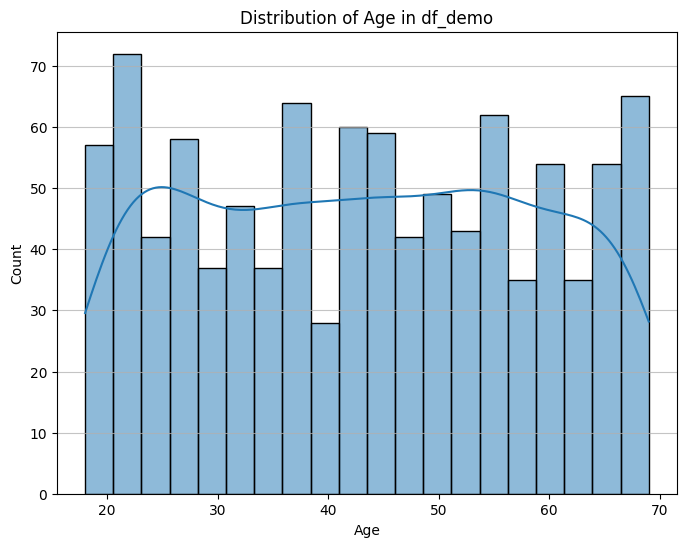

In [15]:
plt.figure(figsize=(8, 6))
sns.histplot(df_demo['Age'], bins=20, kde=True)
plt.title('Distribution of Age in df_demo')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Value Counts for Categorical Features

/tmp/ipykernel_16151/3932608989.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_demo, palette='viridis')


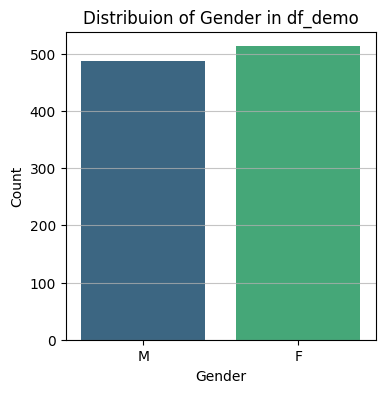

/tmp/ipykernel_16151/3932608989.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_demo, palette='viridis')


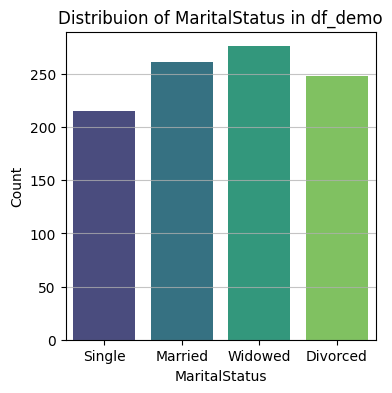

/tmp/ipykernel_16151/3932608989.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_demo, palette='viridis')


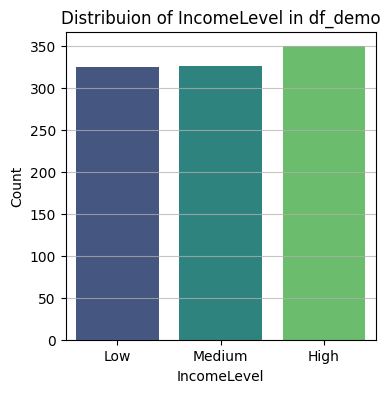

In [16]:
categorical_cols = ['Gender', 'MaritalStatus', 'IncomeLevel']

for col in categorical_cols:
    plt.figure(figsize=(4, 4))
    sns.countplot(x=col, data=df_demo, palette='viridis')
    plt.title(f'Distribuion of {col} in df_demo')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

<Figure size 1000x1000 with 0 Axes>

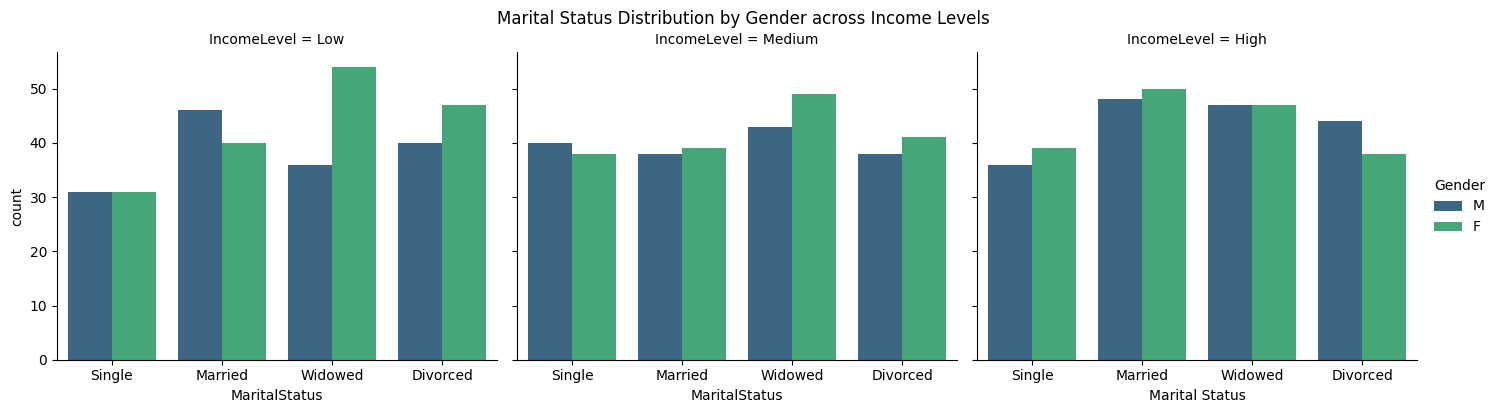

In [17]:
plt.figure(figsize=(10, 10))
sns.catplot(data=df_demo, x='MaritalStatus', hue='Gender', col='IncomeLevel', kind='count', palette='viridis', height=4, aspect=1.2)
plt.suptitle('Marital Status Distribution by Gender across Income Levels', y=1.02) # Adjust suptitle position
plt.xlabel('Marital Status')
plt.ylabel('Count')
#plt.tight_layout()
plt.show()

/tmp/ipykernel_16151/185657420.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_demo, x='IncomeLevel', y='Age', palette='viridis')


Text(0, 0.5, 'Age')

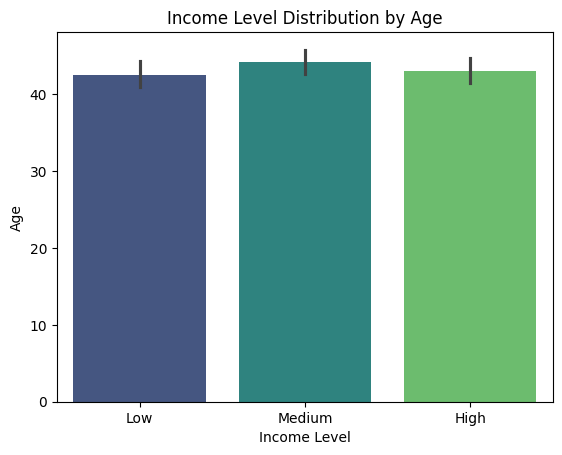

In [18]:
sns.barplot(data=df_demo, x='IncomeLevel', y='Age', palette='viridis')
plt.title('Income Level Distribution by Age')
plt.xlabel('Income Level')
plt.ylabel('Age')

### Outlier

In [19]:
def outlier(df, col_name):
    q1 = df[col_name].quantile(0.25)
    q3 = df[col_name].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")

    print(f"\n--- Outlier Report for {col_name} ---")
    outliers = df[(df[col_name] < lower_bound) | (df[col_name] > upper_bound)]
    print(f"Number of outliers: {len(outliers)}")
    return outliers

age_outlier = outlier(df_demo,'Age')

Q1: 30.0
Q3: 56.0
IQR: 26.0
Lower Bound: -9.0
Upper Bound: 95.0

--- Outlier Report for Age ---
Number of outliers: 0


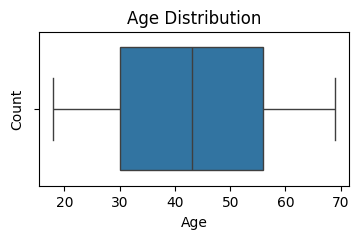

In [20]:
plt.figure(figsize=(4,2))

sns.boxplot(x=df_demo['Age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

## **Table 2 : Transaction_History**

In [21]:
df_trans.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [22]:
df_trans['ProductCategory'].value_counts(normalize=True)

,proportion
ProductCategory,
Books,0.205975
Groceries,0.201820
Electronics,0.198061
Clothing,0.197863
Furniture,0.196280


In [23]:
print(f"The Transaction timeline is {df_trans['TransactionDate'].min()} to {df_trans['TransactionDate'].max()}")

The Transaction timeline is 2022-01-01 00:00:00 to 2022-12-31 00:00:00


In [24]:
amountspent_outlier = outlier(df_trans,'AmountSpent')

Q1: 127.10499999999999
Q3: 373.4125
IQR: 246.30750000000003
Lower Bound: -242.35625000000007
Upper Bound: 742.8737500000001

--- Outlier Report for AmountSpent ---
Number of outliers: 0


In [25]:
df_trans.groupby('ProductCategory')['AmountSpent'].mean()

,AmountSpent
ProductCategory,
Books,249.341969
Clothing,252.450700
Electronics,248.890899
Furniture,246.759899
Groceries,256.013382


In [26]:
df_trans.groupby('ProductCategory').agg(
    Avg_Amount_Spent=('AmountSpent', 'mean'),
    Total_Transactions=('TransactionID', 'count')
).sort_values(by='Total_Transactions', ascending=False)

,Avg_Amount_Spent,Total_Transactions
ProductCategory,,
Books,249.341969,1041
Groceries,256.013382,1020
Electronics,248.890899,1001
Clothing,252.450700,1000
Furniture,246.759899,992


In [27]:
df_trans.groupby('CustomerID')['AmountSpent'].sum().sort_values(ascending=False).head()

,AmountSpent
CustomerID,
481,3386.04
369,3352.34
716,3220.30
37,3166.88
518,3078.60


### Outlier

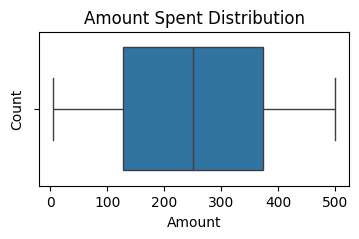

In [28]:
plt.figure(figsize=(4,2))

sns.boxplot(x=df_trans['AmountSpent'])
plt.title('Amount Spent Distribution')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.show()

### Distribution of Product Category

/tmp/ipykernel_16151/2272229508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ProductCategory', data=df_trans, palette='viridis', order=df_trans['ProductCategory'].value_counts().index)


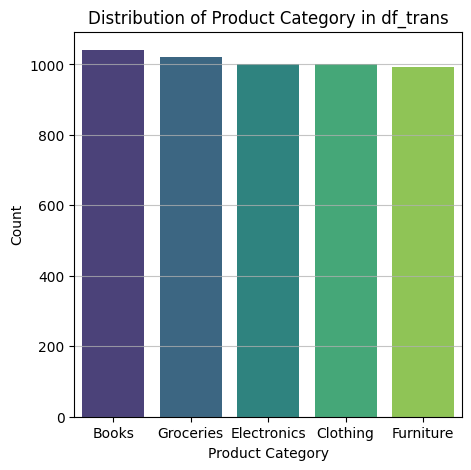

In [29]:
### Distribution of Product Category

plt.figure(figsize=(5, 5))
sns.countplot(x='ProductCategory', data=df_trans, palette='viridis', order=df_trans['ProductCategory'].value_counts().index)
plt.title('Distribution of Product Category in df_trans')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

/tmp/ipykernel_16151/1439265577.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ProductCategory', y='AmountSpent', data=df_trans, palette='viridis')


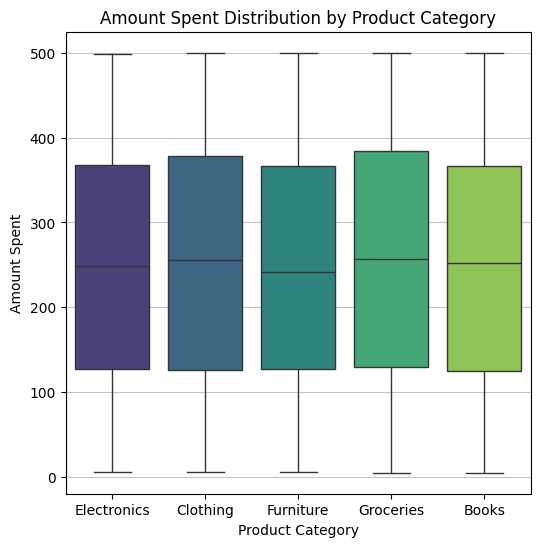

In [30]:
### Amount Spent by Product Category

plt.figure(figsize=(6, 6))
sns.boxplot(x='ProductCategory', y='AmountSpent', data=df_trans, palette='viridis')
plt.title('Amount Spent Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Amount Spent')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Daily Transaction Trends

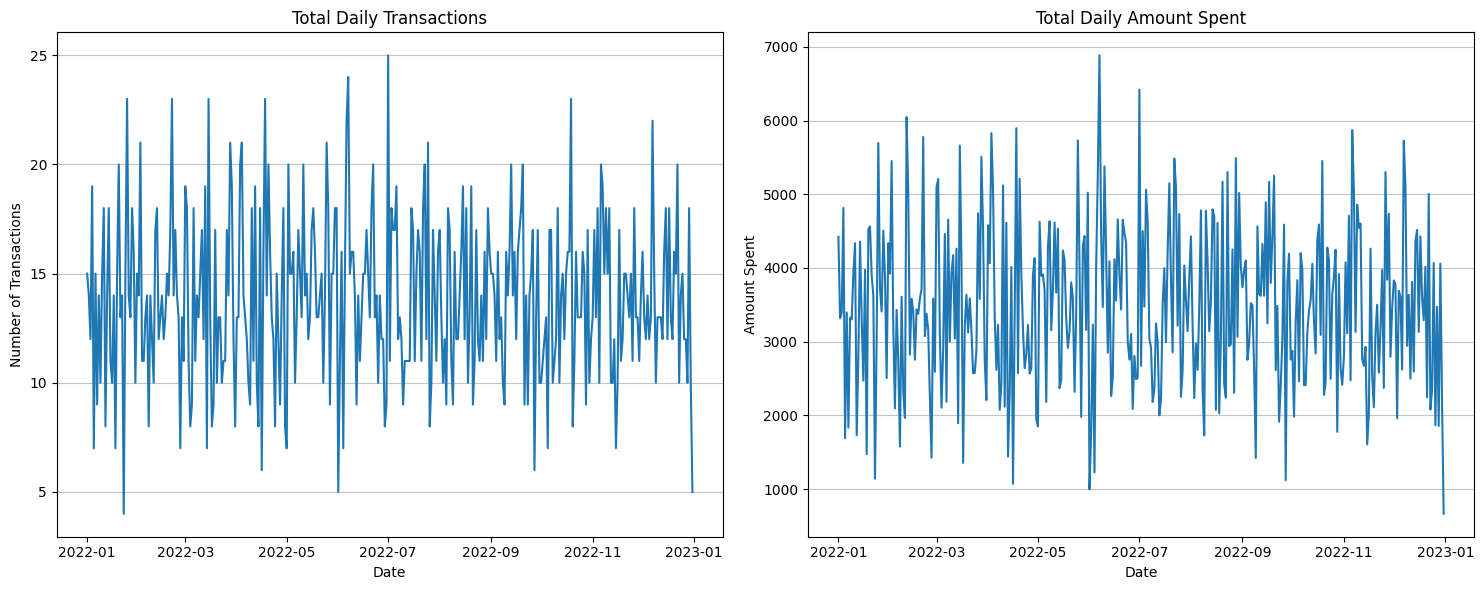

In [31]:
daily_transactions = df_trans.groupby('TransactionDate').agg(
    Total_Transactions=('TransactionID', 'count'),
    Total_Amount_Spent=('AmountSpent', 'sum')
).reset_index()

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.lineplot(x='TransactionDate', y='Total_Transactions', data=daily_transactions)
plt.title('Total Daily Transactions')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
sns.lineplot(x='TransactionDate', y='Total_Amount_Spent', data=daily_transactions)
plt.title('Total Daily Amount Spent')
plt.xlabel('Date')
plt.ylabel('Amount Spent')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

### Monthly Transaction Trends

/tmp/ipykernel_16151/498319839.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Total_Transactions', data=monthly_transactions, palette='viridis')
/tmp/ipykernel_16151/498319839.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Total_Amount_Spent', data=monthly_transactions, palette='magma')


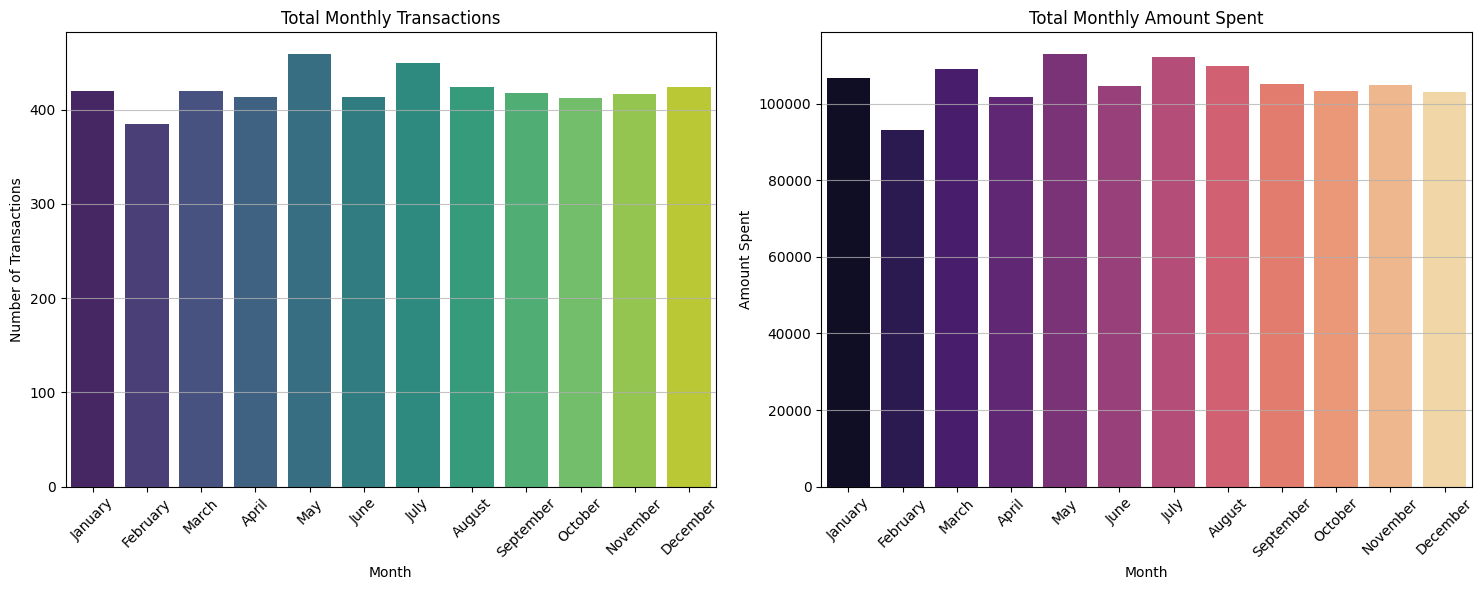

In [32]:
df_trans['Month'] = df_trans['TransactionDate'].dt.month_name()
monthly_transactions = df_trans.groupby('Month').agg(
    Total_Transactions=('TransactionID', 'count'),
    Total_Amount_Spent=('AmountSpent', 'sum')
).reset_index()

# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_transactions['Month'] = pd.Categorical(monthly_transactions['Month'], categories=month_order, ordered=True)
monthly_transactions = monthly_transactions.sort_values('Month')

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Month', y='Total_Transactions', data=monthly_transactions, palette='viridis')
plt.title('Total Monthly Transactions')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
sns.barplot(x='Month', y='Total_Amount_Spent', data=monthly_transactions, palette='magma')
plt.title('Total Monthly Amount Spent')
plt.xlabel('Month')
plt.ylabel('Amount Spent')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

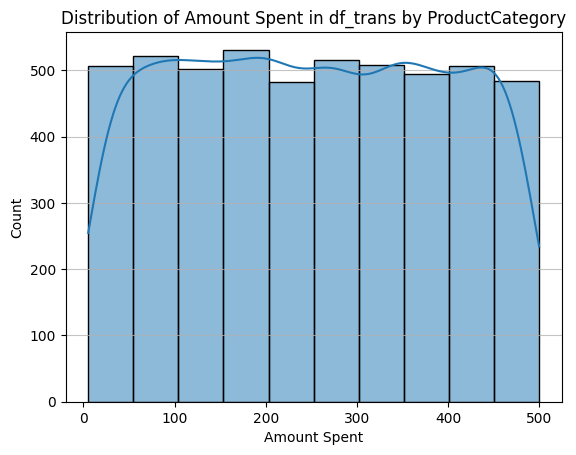

In [33]:
sns.histplot(data=df_trans, x='AmountSpent', bins=10, kde=True)
plt.title('Distribution of Amount Spent in df_trans by ProductCategory')
plt.xlabel('Amount Spent')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

## **Table 3 : Customer_Service**

In [34]:
df_service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [35]:
df_service['InteractionType'].value_counts()

,count
InteractionType,
Feedback,360
Complaint,335
Inquiry,307


In [36]:
df_service['ResolutionStatus'].value_counts()

,count
ResolutionStatus,
Resolved,523
Unresolved,479


In [37]:
print(f"The Service timeline is {df_service['InteractionDate'].min()} to {df_service['InteractionDate'].max()}")

The Service timeline is 2022-01-01 00:00:00 to 2022-12-30 00:00:00


In [38]:
df_service.groupby('CustomerID')['InteractionID'].count().sort_values(ascending=False).head()

,InteractionID
CustomerID,
994,2
990,2
989,2
988,2
4,2


### Distribution

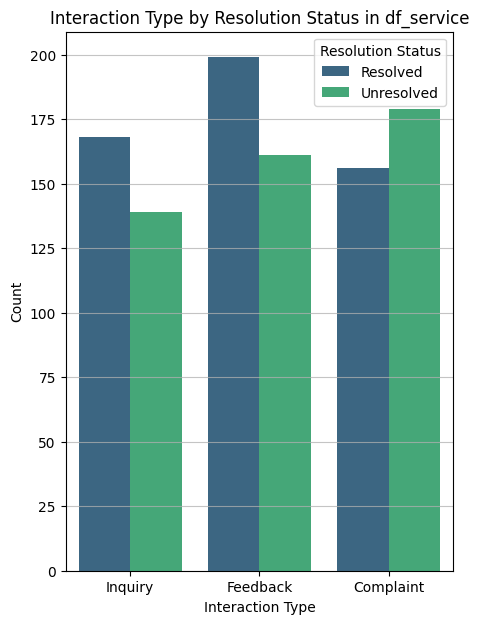

In [39]:
plt.figure(figsize=(5, 7))
sns.countplot(x='InteractionType', hue='ResolutionStatus', data=df_service, palette='viridis')
plt.title('Interaction Type by Resolution Status in df_service')
plt.xlabel('Interaction Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.legend(title='Resolution Status')
plt.show()

/tmp/ipykernel_16151/192030213.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_service, palette='viridis', order=df_service[col].value_counts().index)


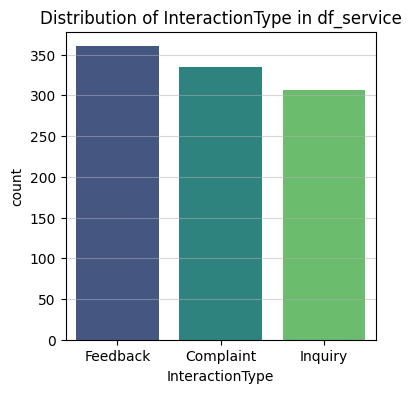

/tmp/ipykernel_16151/192030213.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_service, palette='viridis', order=df_service[col].value_counts().index)


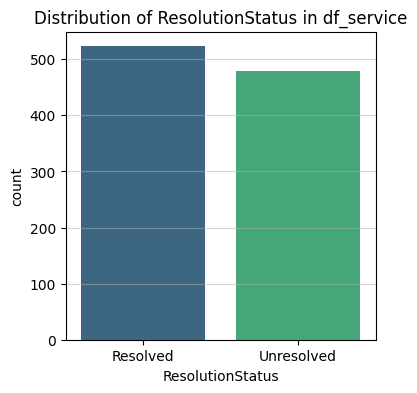

In [40]:
cols = ['InteractionType', 'ResolutionStatus']

for col in cols:
    plt.figure(figsize=(4, 4))
    sns.countplot(x=col, data=df_service, palette='viridis', order=df_service[col].value_counts().index)
    plt.title(f'Distribution of {col} in df_service')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.grid(axis='y', alpha=0.5)
    plt.show()



### Daily Interaction Trends

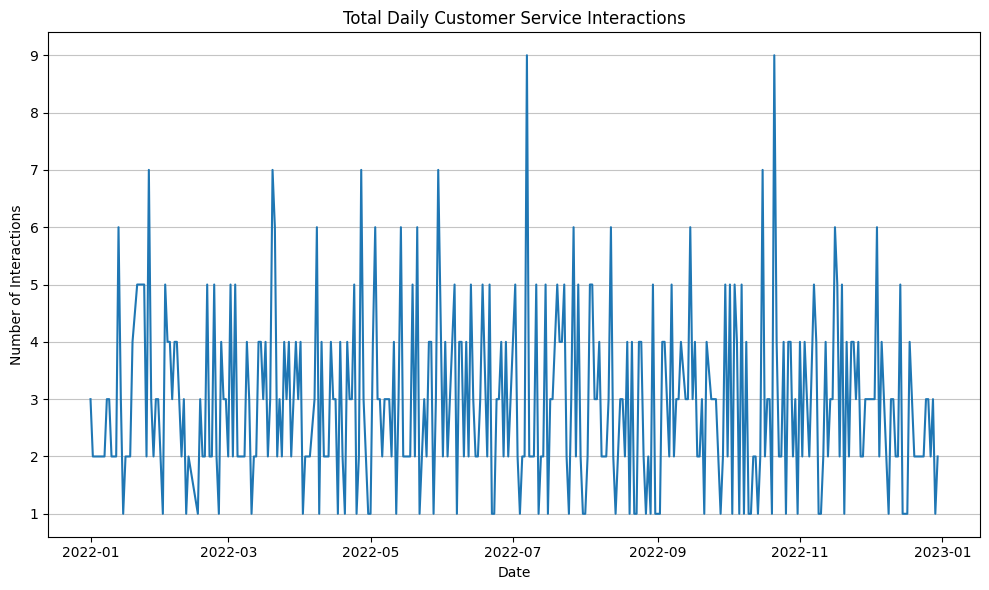

In [41]:
daily_interactions_service = df_service.groupby('InteractionDate').agg(
    Total_Interactions=('InteractionID', 'count')
).reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='InteractionDate', y='Total_Interactions', data=daily_interactions_service)
plt.title('Total Daily Customer Service Interactions')
plt.xlabel('Date')
plt.ylabel('Number of Interactions')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Monthly Interaction Trends

/tmp/ipykernel_16151/869514339.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Total_Interactions', data=monthly_interactions_service, palette='viridis')


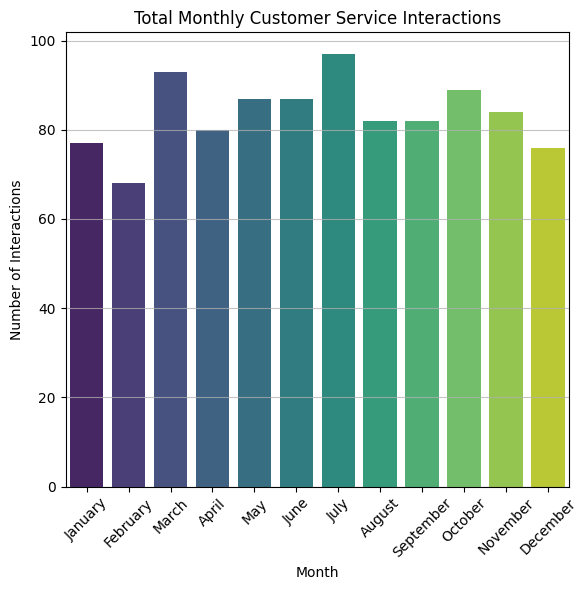

In [42]:
df_service['Month'] = df_service['InteractionDate'].dt.month_name()
monthly_interactions_service = df_service.groupby('Month').agg(
    Total_Interactions=('InteractionID', 'count')
).reset_index()

# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_interactions_service['Month'] = pd.Categorical(monthly_interactions_service['Month'], categories=month_order, ordered=True)
monthly_interactions_service = monthly_interactions_service.sort_values('Month')

plt.figure(figsize=(6, 6))
sns.barplot(x='Month', y='Total_Interactions', data=monthly_interactions_service, palette='viridis')
plt.title('Total Monthly Customer Service Interactions')
plt.xlabel('Month')
plt.ylabel('Number of Interactions')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

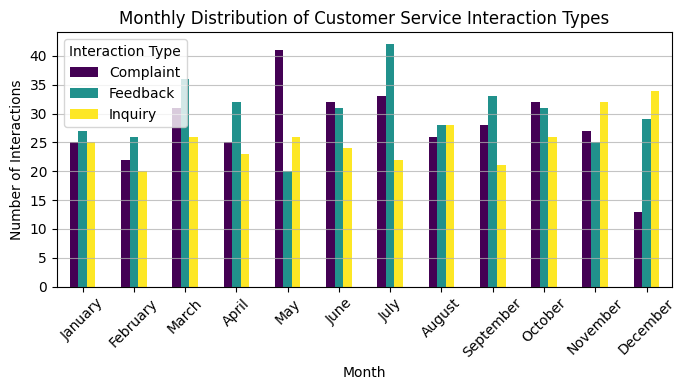

In [43]:
df_service['Month'] = df_service['InteractionDate'].dt.month_name()
monthly_interaction_types = df_service.groupby(['Month', 'InteractionType']).size().unstack(fill_value=0).reset_index()

# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_interaction_types['Month'] = pd.Categorical(monthly_interaction_types['Month'], categories=month_order, ordered=True)
monthly_interaction_types = monthly_interaction_types.sort_values('Month')

monthly_interaction_types.set_index('Month').plot(kind='bar', stacked=False, figsize=(7, 4), colormap='viridis')
plt.title('Monthly Distribution of Customer Service Interaction Types')
plt.xlabel('Month')
plt.ylabel('Number of Interactions')
plt.xticks(rotation=45)
plt.legend(title='Interaction Type')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## **Table 4 : Online_Activity**

In [44]:
df_activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [45]:
df_activity['ServiceUsage'].value_counts()

,count
ServiceUsage,
Online Banking,349
Mobile App,342
Website,309


In [46]:
print(f"The Activity timeline is {df_activity['LastLoginDate'].min()} to {df_activity['LastLoginDate'].max()}")

The Activity timeline is 2023-01-01 00:00:00 to 2023-12-31 00:00:00


Text(0, 0.5, 'Count')

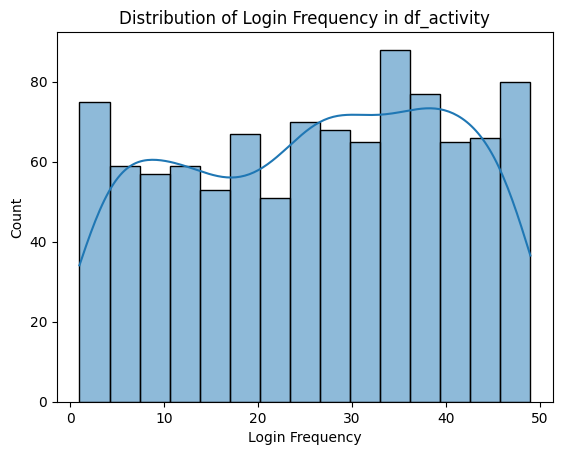

In [47]:
sns.histplot(data=df_activity, x='LoginFrequency', bins=15, kde=True)
plt.title('Distribution of Login Frequency in df_activity')
plt.xlabel('Login Frequency')
plt.ylabel('Count')

/tmp/ipykernel_16151/2413508945.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ServiceUsage', y='LoginFrequency', data=df_activity, palette='viridis')


Text(0, 0.5, 'Login Frequency')

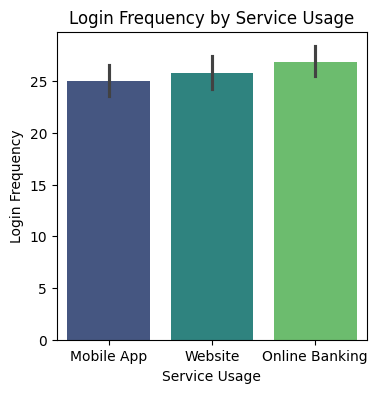

In [48]:
plt.figure(figsize=(4, 4))
sns.barplot(x='ServiceUsage', y='LoginFrequency', data=df_activity, palette='viridis')
plt.title('Login Frequency by Service Usage')
plt.xlabel('Service Usage')
plt.ylabel('Login Frequency')

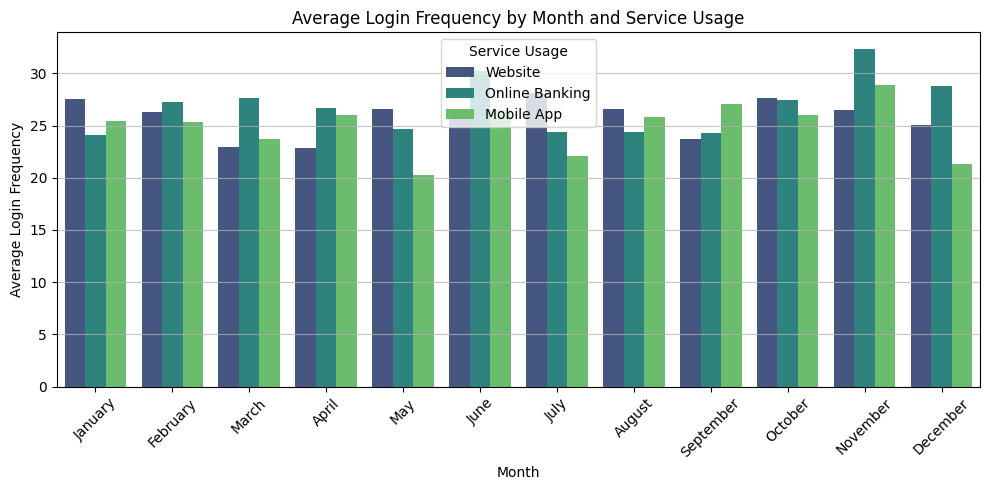

In [49]:
df_activity['Month'] = df_activity['LastLoginDate'].dt.month_name()
monthly_login_trends = df_activity.groupby(['Month', 'ServiceUsage'])['LoginFrequency'].mean().reset_index()

# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_login_trends['Month'] = pd.Categorical(monthly_login_trends['Month'], categories=month_order, ordered=True)
monthly_login_trends = monthly_login_trends.sort_values('Month')

plt.figure(figsize=(10, 5))
sns.barplot(x='Month', y='LoginFrequency', hue='ServiceUsage', data=monthly_login_trends, palette='viridis')
plt.title('Average Login Frequency by Month and Service Usage')
plt.xlabel('Month')
plt.ylabel('Average Login Frequency')
plt.xticks(rotation=45)
plt.legend(title='Service Usage')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## **Table 5 : Churn_Status**

In [50]:
df_churn.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [51]:
df_churn['ChurnStatus'].value_counts()

,count
ChurnStatus,
0,796
1,204


/tmp/ipykernel_16151/2719086143.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ChurnStatus', data=df_churn, palette='viridis')


Text(0, 0.5, 'Count')

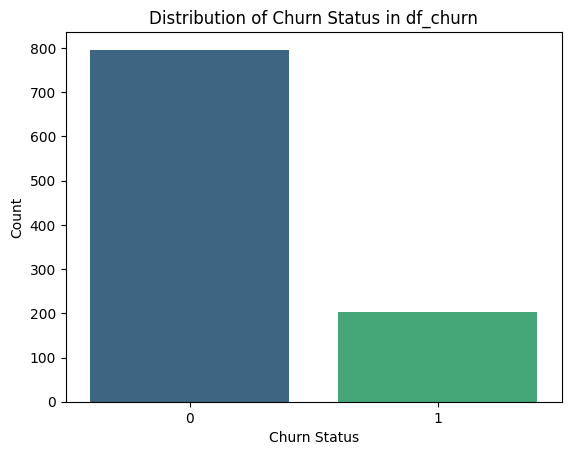

In [52]:
sns.countplot(x='ChurnStatus', data=df_churn, palette='viridis')
plt.title('Distribution of Churn Status in df_churn')
plt.xlabel('Churn Status')
plt.ylabel('Count')

## **Aggregation**

In [53]:
today = pd.to_datetime('2024-01-01')
today

Timestamp('2024-01-01 00:00:00')

### Sheet A: Online_Activity

In [54]:
#Sheet A: Online_Activity (Recency & Frequency)

df_activity['LastLoginDate'] = pd.to_datetime(df_activity['LastLoginDate'])

# Create the new column
df_activity['Days_Since_Last_Login'] = (today - df_activity['LastLoginDate']).dt.days


In [55]:
df_activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage,Month,Days_Since_Last_Login
0,1,2023-10-21,34,Mobile App,October,72
1,2,2023-12-05,5,Website,December,27
2,3,2023-11-15,3,Website,November,47
3,4,2023-08-25,2,Website,August,129
4,5,2023-10-27,41,Website,October,66


In [56]:
# Aggregation: 1 row per customer
# We take the SUM of logins (Frequency) and the MIN of days since (the most recent login)
df_activity_agg = df_activity.groupby('CustomerID').agg(
    Total_Logins=('LoginFrequency', 'sum'),
    Recency_Login=('Days_Since_Last_Login', 'min'),
    Service=('ServiceUsage', lambda x: x.mode()[0] if not x.mode().empty else None),
    Last_Login_Month=('Month', lambda x: x.mode()[0] if not x.mode().empty else None)
).reset_index()

In [57]:
df_activity_agg.head()

,CustomerID,Total_Logins,Recency_Login,Service,Last_Login_Month
0,1,34,72,Mobile App,October
1,2,5,27,Website,December
2,3,3,47,Website,November
3,4,2,129,Website,August
4,5,41,66,Website,October


### Sheet B: Transaction_History

In [58]:
df_trans.head(10)

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory,Month
0,1,7194,2022-03-27,416.50,Electronics,March
1,2,7250,2022-08-08,54.96,Clothing,August
2,2,9660,2022-07-25,197.50,Electronics,July
3,2,2998,2022-01-25,101.31,Furniture,January
4,2,1228,2022-07-24,397.37,Clothing,July
5,2,8903,2022-01-09,285.21,Electronics,January
6,2,3527,2022-09-16,311.34,Electronics,September
7,2,9279,2022-11-19,199.73,Groceries,November
8,3,9839,2022-10-08,241.06,Books,October
9,3,7364,2022-08-15,51.07,Clothing,August


In [59]:
#Sheet B: Transaction_History (Monetary & Frequency)

df_trans_agg = df_trans.groupby('CustomerID').agg(
    Total_spend = ('AmountSpent','sum'),
    Transaction_Count = ('TransactionID','count'),
    Most_Frequent_Product_Category=('ProductCategory', lambda x: x.mode()[0] if not x.mode().empty else None),
    Distinct_Product_Categories=('ProductCategory','nunique')
).reset_index()

In [60]:
df_trans_agg.head()

,CustomerID,Total_spend,Transaction_Count,Most_Frequent_Product_Category,Distinct_Product_Categories
0,1,416.50,1,Electronics,1
1,2,1547.42,7,Electronics,4
2,3,1702.98,6,Furniture,4
3,4,917.29,5,Electronics,4
4,5,2001.49,8,Electronics,3


In [61]:
if 'TransactionDate' in df_trans.columns and not pd.api.types.is_datetime64_any_dtype(df_trans['TransactionDate']):
    df_trans['TransactionDate'] = pd.to_datetime(df_trans['TransactionDate'])
if 'Month' not in df_trans.columns:
    df_trans['Month'] = df_trans['TransactionDate'].dt.month_name()

def get_most_active_month_complex(df_customer_group):
    if df_customer_group.empty:
        return None

    # Calculate transaction counts per month
    monthly_counts = df_customer_group.groupby('Month').size()

    # Get months with the highest transaction count
    max_count = monthly_counts.max()
    most_frequent_months = monthly_counts[monthly_counts == max_count].index.tolist()

    if len(most_frequent_months) == 1:
        # No tie in frequency, return that month
        return most_frequent_months[0]
    else:
        # Tie in frequency, use amount spent as tie-breaker
        monthly_spend = df_customer_group.groupby('Month')['AmountSpent'].sum()
        # Filter spend for only the most frequent months
        tied_months_spend = monthly_spend[monthly_spend.index.isin(most_frequent_months)]
        # Return the month with the highest spend among the tied months
        return tied_months_spend.idxmax()

# Define a helper function to apply to each customer group
def aggregate_transaction_months(group):
    num_active_months = group['Month'].nunique()
    most_active_month = get_most_active_month_complex(group)
    return pd.Series({
        'Number_of_Active_Months': num_active_months,
        'Most_Active_Month': most_active_month
    })

# Use .apply() to pass the entire group DataFrame to the helper function
df_trans_month_agg = df_trans.groupby('CustomerID').apply(aggregate_transaction_months, include_groups=False).reset_index()

In [62]:
df_trans_month_agg.head()

,CustomerID,Number_of_Active_Months,Most_Active_Month
0,1,1,March
1,2,5,July
2,3,6,September
3,4,3,December
4,5,6,December


### Sheet C: Customer_Service

In [63]:
df_service.head(10)

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus,Month
0,1,6363,2022-03-31,Inquiry,Resolved,March
1,2,3329,2022-03-17,Inquiry,Resolved,March
2,3,9976,2022-08-24,Inquiry,Resolved,August
3,4,7354,2022-11-18,Inquiry,Resolved,November
4,4,5393,2022-07-03,Inquiry,Unresolved,July
5,6,2358,2022-05-05,Feedback,Resolved,May
6,8,4191,2022-04-29,Inquiry,Unresolved,April
7,8,8937,2022-09-13,Feedback,Unresolved,September
8,9,7813,2022-08-15,Inquiry,Resolved,August
9,11,6610,2022-10-28,Feedback,Resolved,October


In [64]:
#Sheet C: Customer_Service (The "Friction" Metric)

df_service_agg = df_service.groupby('CustomerID').agg(
    Total_Service_Calls=('InteractionID', 'count'),
    Unresolved_Issues=('ResolutionStatus', lambda x: (x == 'Unresolved').sum())
).reset_index()

In [65]:
df_service_agg.head(6)

,CustomerID,Total_Service_Calls,Unresolved_Issues
0,1,1,0
1,2,1,0
2,3,1,0
3,4,2,1
4,6,1,0
5,8,2,2


## **Merge**

In [66]:
# 1. Start with the 'Core' of the bank: Demographics
master_df = df_demo.copy()

In [67]:
master_df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [68]:
df_activity_agg.head()

,CustomerID,Total_Logins,Recency_Login,Service,Last_Login_Month
0,1,34,72,Mobile App,October
1,2,5,27,Website,December
2,3,3,47,Website,November
3,4,2,129,Website,August
4,5,41,66,Website,October


In [69]:
df_trans_agg.head()

,CustomerID,Total_spend,Transaction_Count,Most_Frequent_Product_Category,Distinct_Product_Categories
0,1,416.50,1,Electronics,1
1,2,1547.42,7,Electronics,4
2,3,1702.98,6,Furniture,4
3,4,917.29,5,Electronics,4
4,5,2001.49,8,Electronics,3


In [70]:
df_trans_month_agg.head()

,CustomerID,Number_of_Active_Months,Most_Active_Month
0,1,1,March
1,2,5,July
2,3,6,September
3,4,3,December
4,5,6,December


In [71]:
df_service_agg.head()

,CustomerID,Total_Service_Calls,Unresolved_Issues
0,1,1,0
1,2,1,0
2,3,1,0
3,4,2,1
4,6,1,0


In [72]:
df_churn.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [73]:
# 2. Add the Behavior (Activity, Transactions, Service)
master_df = master_df.merge(df_activity_agg, on='CustomerID', how='left')
master_df = master_df.merge(df_trans_agg, on='CustomerID', how='left')
master_df = master_df.merge(df_trans_month_agg, on='CustomerID', how='left') # Merge the monthly aggregation dataframe
master_df = master_df.merge(df_service_agg, on='CustomerID', how='left')

In [74]:
# 3. Add the Target (Did they churn?)
master_df = master_df.merge(df_churn, on='CustomerID', how='left')

In [75]:
# Fill missing counts/sums with 0
cols_to_fix = ['Total_Logins', 'Total_spend', 'Transaction_Count', 'Total_Service_Calls', 'Unresolved_Issues']
master_df[cols_to_fix] = master_df[cols_to_fix].fillna(0)

# For Recency, if they never logged in, we'll set it to a very high number (e.g., 999 days)
master_df['Recency_Login'] = master_df['Recency_Login'].fillna(999)

print("Master Table is Ready!")
master_df.head()

Master Table is Ready!


,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,Total_Logins,Recency_Login,Service,Last_Login_Month,Total_spend,Transaction_Count,Most_Frequent_Product_Category,Distinct_Product_Categories,Number_of_Active_Months,Most_Active_Month,Total_Service_Calls,Unresolved_Issues,ChurnStatus
0,1,62,M,Single,Low,34,72,Mobile App,October,416.50,1,Electronics,1,1,March,1.0,0.0,0
1,2,65,M,Married,Low,5,27,Website,December,1547.42,7,Electronics,4,5,July,1.0,0.0,1
2,3,18,M,Single,Low,3,47,Website,November,1702.98,6,Furniture,4,6,September,1.0,0.0,0
3,4,21,M,Widowed,Low,2,129,Website,August,917.29,5,Electronics,4,3,December,2.0,1.0,0
4,5,21,M,Divorced,Medium,41,66,Website,October,2001.49,8,Electronics,3,6,December,0.0,0.0,0


# **Final Dataset**

In [76]:
master_df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,Total_Logins,Recency_Login,Service,Last_Login_Month,Total_spend,Transaction_Count,Most_Frequent_Product_Category,Distinct_Product_Categories,Number_of_Active_Months,Most_Active_Month,Total_Service_Calls,Unresolved_Issues,ChurnStatus
0,1,62,M,Single,Low,34,72,Mobile App,October,416.50,1,Electronics,1,1,March,1.0,0.0,0
1,2,65,M,Married,Low,5,27,Website,December,1547.42,7,Electronics,4,5,July,1.0,0.0,1
2,3,18,M,Single,Low,3,47,Website,November,1702.98,6,Furniture,4,6,September,1.0,0.0,0
3,4,21,M,Widowed,Low,2,129,Website,August,917.29,5,Electronics,4,3,December,2.0,1.0,0
4,5,21,M,Divorced,Medium,41,66,Website,October,2001.49,8,Electronics,3,6,December,0.0,0.0,0


In [77]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=master_df)

https://docs.google.com/spreadsheets/d/1w83ZmlnHI7OJf-A70e5R3dpTjsKf5cGWkMtjSh5K8ME/edit#gid=0


In [78]:
master_df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
MaritalStatus,0
IncomeLevel,0
Total_Logins,0
Recency_Login,0
Service,0
Last_Login_Month,0
Total_spend,0


In [79]:
display(master_df.describe())

,CustomerID,Age,Total_Logins,Recency_Login,Total_spend,Transaction_Count,Distinct_Product_Categories,Number_of_Active_Months,Total_Service_Calls,Unresolved_Issues,ChurnStatus
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.267000,25.912000,179.105000,1267.074950,5.054000,3.097000,4.104000,1.002000,0.479000,0.204000
std,288.819436,15.242311,14.055953,104.897299,738.590013,2.603433,1.252661,1.959853,0.816494,0.621245,0.403171
min,1.000000,18.000000,1.000000,1.000000,9.800000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,250.750000,30.000000,13.750000,91.750000,626.685000,3.000000,2.000000,2.750000,0.000000,0.000000,0.000000
50%,500.500000,43.000000,27.000000,174.500000,1232.880000,5.000000,3.000000,4.000000,1.000000,0.000000,0.000000
75%,750.250000,56.000000,38.000000,268.000000,1791.902500,7.000000,4.000000,6.000000,2.000000,1.000000,0.000000
max,1000.000000,69.000000,49.000000,365.000000,3386.040000,9.000000,5.000000,9.000000,2.000000,2.000000,1.000000


## **1. Correlation Matrix**

In [80]:
correlation_matrix = master_df.corr(numeric_only=True)
display(correlation_matrix)

,CustomerID,Age,Total_Logins,Recency_Login,Total_spend,Transaction_Count,Distinct_Product_Categories,Number_of_Active_Months,Total_Service_Calls,Unresolved_Issues,ChurnStatus
CustomerID,1.000000,0.008962,0.011437,-0.018223,-0.021198,0.006218,-0.021668,0.001763,-0.065034,-0.013269,-0.011528
Age,0.008962,1.000000,-0.022826,-0.052631,0.010930,0.008667,-0.009327,0.015120,-0.019266,-0.033288,0.029407
Total_Logins,0.011437,-0.022826,1.000000,-0.030715,0.012015,-0.013985,-0.028225,-0.016165,-0.002514,0.023173,-0.081615
Recency_Login,-0.018223,-0.052631,-0.030715,1.000000,0.006637,-0.033776,-0.043591,-0.020435,0.030186,0.054495,0.009055
Total_spend,-0.021198,0.010930,0.012015,0.006637,1.000000,0.898256,0.761467,0.844055,0.089723,0.074169,0.001324
Transaction_Count,0.006218,0.008667,-0.013985,-0.033776,0.898256,1.000000,0.854450,0.934502,0.065876,0.055785,-0.008598
Distinct_Product_Categories,-0.021668,-0.009327,-0.028225,-0.043591,0.761467,0.854450,1.000000,0.808501,0.062447,0.052142,0.008348
Number_of_Active_Months,0.001763,0.015120,-0.016165,-0.020435,0.844055,0.934502,0.808501,1.000000,0.075561,0.053591,-0.010408
Total_Service_Calls,-0.065034,-0.019266,-0.002514,0.030186,0.089723,0.065876,0.062447,0.075561,1.000000,0.643417,0.004841
Unresolved_Issues,-0.013269,-0.033288,0.023173,0.054495,0.074169,0.055785,0.052142,0.053591,0.643417,1.000000,0.005132


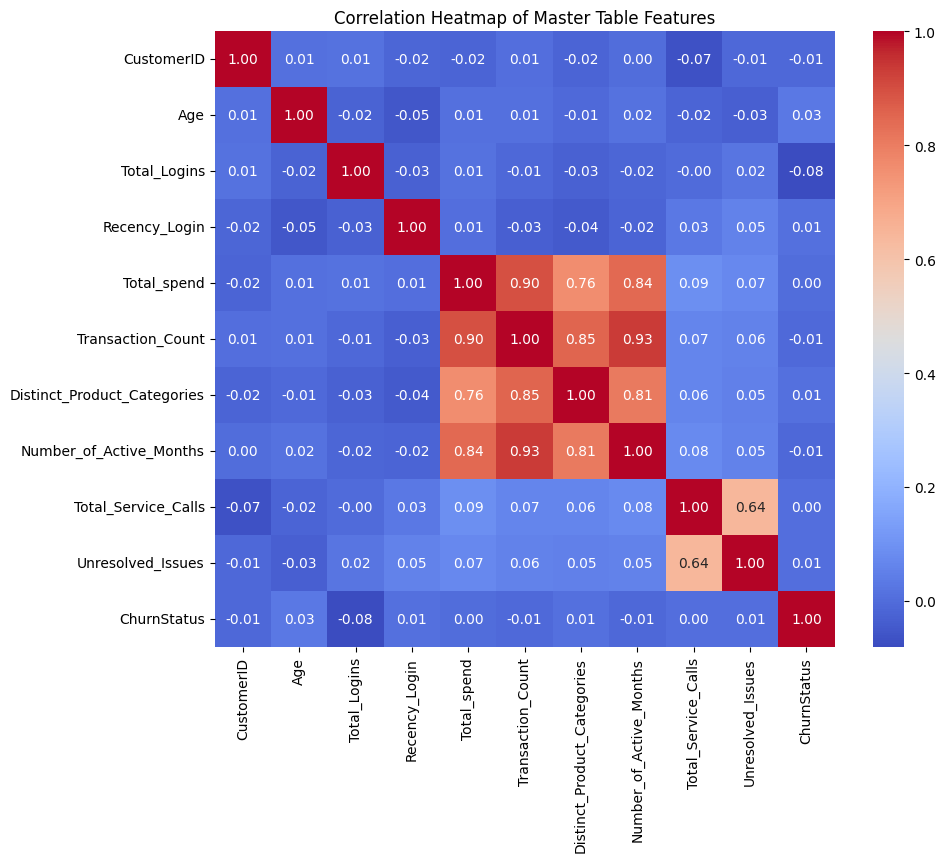

In [81]:
plt.figure(figsize=(10, 8))
numeric_df = master_df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Master Table Features')
plt.savefig('correlation_heatmap.png')

## **2. Categorical Patterns/Crosstabs**

In [82]:
# Crosstab for Gender vs ChurnStatus
crosstab_gender = pd.crosstab(master_df['Gender'], master_df['ChurnStatus'], normalize='index', margins=True)
display(crosstab_gender)

ChurnStatus,0,1
Gender,,
F,0.803119,0.196881
M,0.788501,0.211499
All,0.796000,0.204000


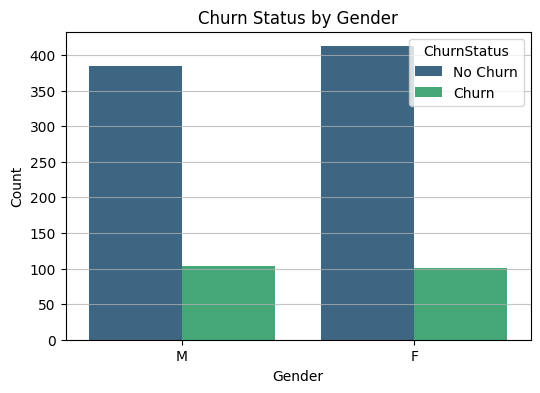

In [83]:
# Visualize Gender vs ChurnStatus
plt.figure(figsize=(6, 4))
sns.countplot(data=master_df, x='Gender', hue='ChurnStatus', palette='viridis')
plt.title('Churn Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='ChurnStatus', labels=['No Churn', 'Churn'])
plt.grid(axis='y', alpha=0.75)
plt.show()

In [84]:
# Crosstab for MaritalStatus vs ChurnStatus
crosstab_marital_status = pd.crosstab(master_df['MaritalStatus'], master_df['ChurnStatus'], normalize='index', margins=True)
display(crosstab_marital_status)

ChurnStatus,0,1
MaritalStatus,,
Divorced,0.814516,0.185484
Married,0.770115,0.229885
Single,0.795349,0.204651
Widowed,0.804348,0.195652
All,0.796000,0.204000


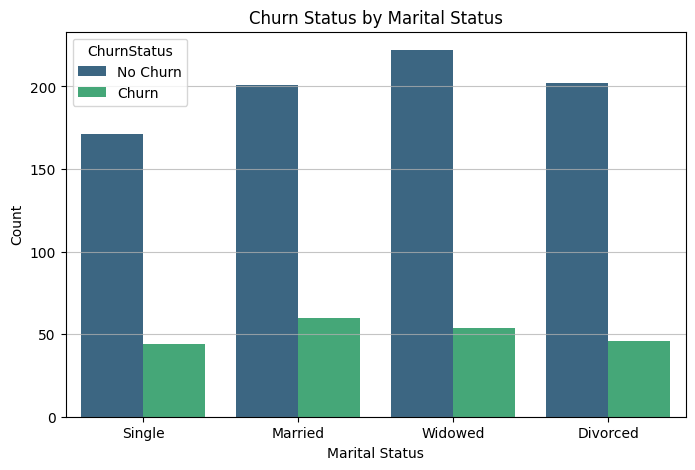

In [85]:
# Visualize MaritalStatus vs ChurnStatus
plt.figure(figsize=(8, 5))
sns.countplot(data=master_df, x='MaritalStatus', hue='ChurnStatus', palette='viridis')
plt.title('Churn Status by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.legend(title='ChurnStatus', labels=['No Churn', 'Churn'])
plt.grid(axis='y', alpha=0.75)
plt.show()

In [86]:
# Crosstab for IncomeLevel vs ChurnStatus
crosstab_income_level = pd.crosstab(master_df['IncomeLevel'], master_df['ChurnStatus'], normalize='index', margins=True)
display(crosstab_income_level)

ChurnStatus,0,1
IncomeLevel,,
High,0.808023,0.191977
Low,0.778462,0.221538
Medium,0.800613,0.199387
All,0.796000,0.204000


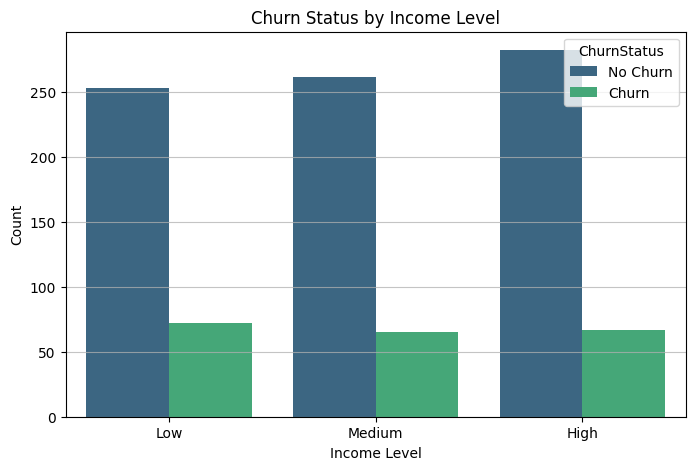

In [87]:
# Visualize IncomeLevel vs ChurnStatus
plt.figure(figsize=(8, 5))
sns.countplot(data=master_df, x='IncomeLevel', hue='ChurnStatus', palette='viridis')
plt.title('Churn Status by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.legend(title='ChurnStatus', labels=['No Churn', 'Churn'])
plt.grid(axis='y', alpha=0.75)
plt.show()

In [88]:
remaining_categorical_features = [
    'Service',
    'Last_Login_Month',
    'Most_Frequent_Product_Category',
    'Most_Active_Month'
]

for feature in remaining_categorical_features:
    print(f"\n--- Analyzing {feature} vs ChurnStatus ---")

    # Create normalized crosstab for churn rates
    normalized_crosstab = pd.crosstab(master_df[feature], master_df['ChurnStatus'], normalize='index')
    print("\nNormalized Crosstab (Churn Rates):")
    display(normalized_crosstab)


--- Analyzing Service vs ChurnStatus ---

Normalized Crosstab (Churn Rates):


ChurnStatus,0,1
Service,,
Mobile App,0.769006,0.230994
Online Banking,0.799427,0.200573
Website,0.822006,0.177994



--- Analyzing Last_Login_Month vs ChurnStatus ---

Normalized Crosstab (Churn Rates):


ChurnStatus,0,1
Last_Login_Month,,
April,0.783784,0.216216
August,0.744898,0.255102
December,0.820225,0.179775
February,0.794521,0.205479
January,0.833333,0.166667
July,0.773810,0.226190
June,0.782178,0.217822
March,0.771429,0.228571
May,0.808824,0.191176



--- Analyzing Most_Frequent_Product_Category vs ChurnStatus ---

Normalized Crosstab (Churn Rates):


ChurnStatus,0,1
Most_Frequent_Product_Category,,
Books,0.805112,0.194888
Clothing,0.818584,0.181416
Electronics,0.758242,0.241758
Furniture,0.780142,0.219858
Groceries,0.804348,0.195652



--- Analyzing Most_Active_Month vs ChurnStatus ---

Normalized Crosstab (Churn Rates):


ChurnStatus,0,1
Most_Active_Month,,
April,0.820225,0.179775
August,0.752688,0.247312
December,0.819277,0.180723
February,0.800000,0.200000
January,0.777778,0.222222
July,0.818182,0.181818
June,0.855072,0.144928
March,0.790698,0.209302
May,0.775510,0.224490


## **3. Deep Dive & Intersection Analysis**

### **1. Identifying Patterns**

In [89]:
crosstab_income_service = pd.crosstab([master_df['IncomeLevel'], master_df['Service']], master_df['ChurnStatus'], normalize='index')
crosstab_income_service_sorted = crosstab_income_service.sort_values(by=1, ascending=False)
display(crosstab_income_service_sorted)

ChurnStatus                        0         1
IncomeLevel Service                           
Medium      Mobile App      0.738739  0.261261
Low         Online Banking  0.763158  0.236842
            Mobile App      0.769912  0.230088
High        Online Banking  0.782946  0.217054
            Mobile App      0.796610  0.203390
Low         Website         0.806122  0.193878
Medium      Website         0.807339  0.192661
High        Website         0.852941  0.147059
Medium      Online Banking  0.858491  0.141509

In [90]:
crosstab_marital_gender = pd.crosstab([master_df['MaritalStatus'], master_df['Gender']], master_df['ChurnStatus'], normalize='index')
crosstab_marital_gender_sorted = crosstab_marital_gender.sort_values(by=1, ascending=False)
display(crosstab_marital_gender_sorted)

ChurnStatus                  0         1
MaritalStatus Gender                    
Married       M       0.765152  0.234848
              F       0.775194  0.224806
Widowed       M       0.777778  0.222222
Single        M       0.794393  0.205607
              F       0.796296  0.203704
Divorced      F       0.809524  0.190476
              M       0.819672  0.180328
Widowed       F       0.826667  0.173333

In [91]:
crosstab_prCat_income = pd.crosstab([master_df['Most_Frequent_Product_Category'], master_df['IncomeLevel']], master_df['ChurnStatus'], normalize='index')
crosstab_prCat_income_sorted = crosstab_prCat_income.sort_values(by=1, ascending=False)
display(crosstab_prCat_income_sorted)

,ChurnStatus,0,1
Most_Frequent_Product_Category,IncomeLevel,,
Electronics,Low,0.707692,0.292308
Furniture,High,0.734375,0.265625
Groceries,Medium,0.769231,0.230769
Electronics,Medium,0.779661,0.220339
Books,Medium,0.781250,0.218750
Electronics,High,0.793103,0.206897
Clothing,Low,0.794118,0.205882
Furniture,Low,0.794872,0.205128
Books,Low,0.796296,0.203704


### **2. Identifying Anomalies**

In [92]:
print('--- Anomalies: Churned despite being in a low-churn group ---')
# Based on crosstab_income_service, 'High Income' and 'Website' service usage has a low churn rate.
low_churn_group_churned = master_df[(master_df['IncomeLevel'] == 'High') &
                                    (master_df['Service'] == 'Website') &
                                    (master_df['ChurnStatus'] == 1)]
print(f"Number of customers with High Income and Website usage who churned: {len(low_churn_group_churned)}")
display(low_churn_group_churned.head())

print('\n--- Anomalies: Did not churn despite being in a high-churn group ---')
# Based on crosstab_income_service, 'Medium Income' and 'Mobile App' service usage has a high churn rate.
high_churn_group_not_churned = master_df[(master_df['IncomeLevel'] == 'Medium') &
                                        (master_df['Service'] == 'Mobile App') &
                                        (master_df['ChurnStatus'] == 0)]
print(f"Number of customers with Medium Income and Mobile App usage who did not churn: {len(high_churn_group_not_churned)}")
display(high_churn_group_not_churned.head())

--- Anomalies: Churned despite being in a low-churn group ---
Number of customers with High Income and Website usage who churned: 15


,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,Total_Logins,Recency_Login,Service,Last_Login_Month,Total_spend,Transaction_Count,Most_Frequent_Product_Category,Distinct_Product_Categories,Number_of_Active_Months,Most_Active_Month,Total_Service_Calls,Unresolved_Issues,ChurnStatus
17,18,56,F,Married,High,37,38,Website,November,951.38,5,Books,3,5,April,1.0,1.0,1
67,68,59,F,Divorced,High,5,160,Website,July,886.48,4,Books,4,4,October,2.0,2.0,1
110,111,23,F,Widowed,High,33,198,Website,June,613.18,2,Books,2,2,January,1.0,1.0,1
175,176,26,F,Single,High,15,100,Website,September,936.78,6,Clothing,4,5,January,0.0,0.0,1
261,262,59,F,Divorced,High,30,331,Website,February,2940.59,9,Books,5,7,October,2.0,2.0,1



--- Anomalies: Did not churn despite being in a high-churn group ---
Number of customers with Medium Income and Mobile App usage who did not churn: 82


,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,Total_Logins,Recency_Login,Service,Last_Login_Month,Total_spend,Transaction_Count,Most_Frequent_Product_Category,Distinct_Product_Categories,Number_of_Active_Months,Most_Active_Month,Total_Service_Calls,Unresolved_Issues,ChurnStatus
23,24,55,M,Widowed,Medium,12,89,Mobile App,October,1143.22,5,Clothing,4,5,February,1.0,0.0,0
26,27,26,M,Widowed,Medium,22,92,Mobile App,October,2210.60,8,Clothing,5,5,May,1.0,1.0,0
41,42,47,M,Widowed,Medium,10,168,Mobile App,July,530.61,3,Books,2,3,July,0.0,0.0,0
51,52,28,M,Widowed,Medium,6,319,Mobile App,February,401.25,1,Groceries,1,1,February,0.0,0.0,0
69,70,49,F,Married,Medium,10,292,Mobile App,March,2453.98,7,Furniture,4,4,December,0.0,0.0,0


### **3.Exploring Non-Linear Patterns: Age vs. Churn**

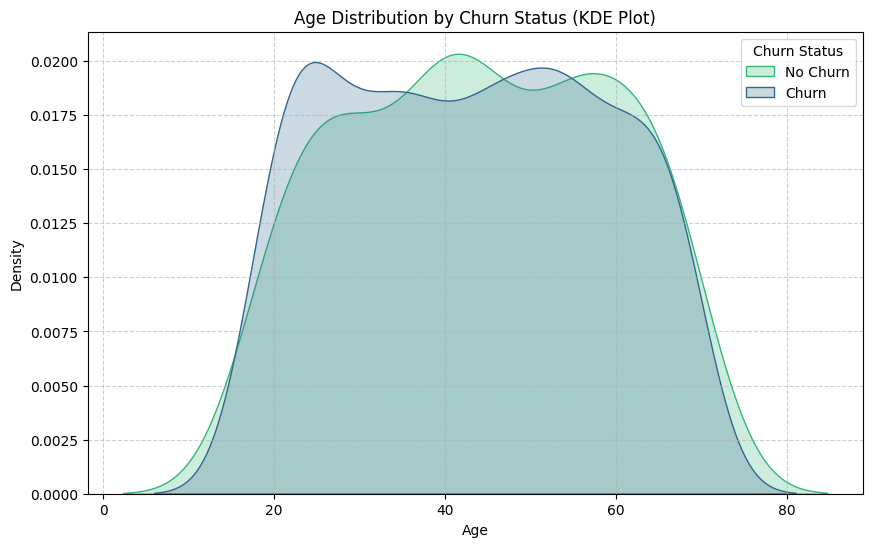

In [93]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=master_df, x='Age', hue='ChurnStatus', fill=True, common_norm=False, palette='viridis')
plt.title('Age Distribution by Churn Status (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Churn Status', labels=['No Churn', 'Churn'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

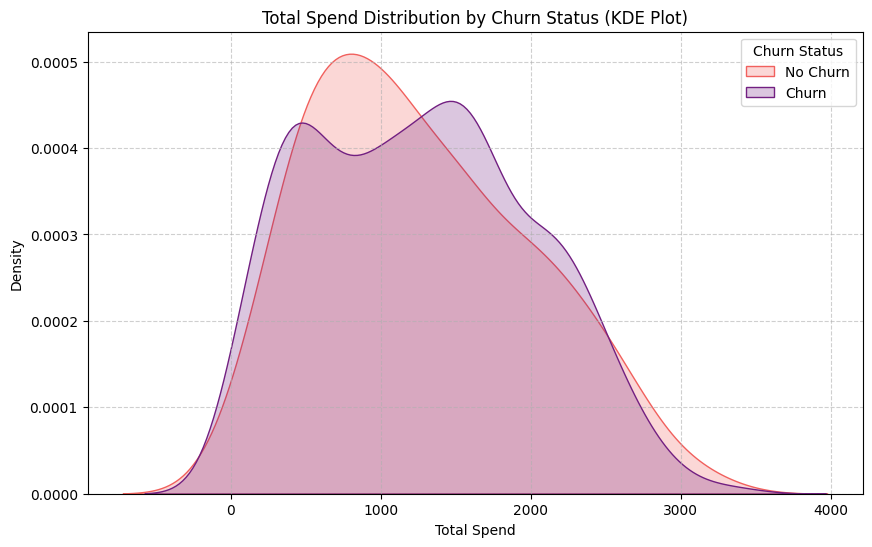

In [94]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=master_df, x='Total_spend', hue='ChurnStatus', fill=True, common_norm=False, palette='magma')
plt.title('Total Spend Distribution by Churn Status (KDE Plot)')
plt.xlabel('Total Spend')
plt.ylabel('Density')
plt.legend(title='Churn Status', labels=['No Churn', 'Churn'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

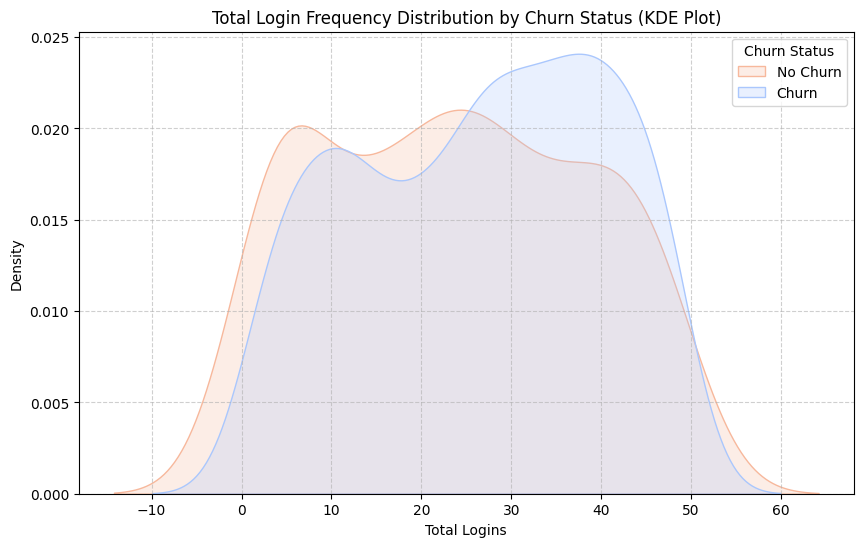

In [95]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=master_df, x='Total_Logins', hue='ChurnStatus', fill=True, common_norm=False, palette='coolwarm')
plt.title('Total Login Frequency Distribution by Churn Status (KDE Plot)')
plt.xlabel('Total Logins')
plt.ylabel('Density')
plt.legend(title='Churn Status', labels=['No Churn', 'Churn'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Statistical Tests**

### **1. The Chi-Square Test (Categories)**

In [96]:
from scipy.stats import chi2_contingency

# Test Service vs Churn
contingency_table = pd.crosstab(master_df['Service'], master_df['ChurnStatus'])
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"Chi-Square P-value: {p}")
if p < 0.05:
    print("Significant: Service Usage is a real predictor of churn.")
else:
    print("Not significant: Service Usage is NOT a real predictor of churn.")

Chi-Square P-value: 0.2408773659514701
Not significant: Service Usage is NOT a real predictor of churn.


In [97]:
from scipy.stats import chi2_contingency

# Test IncomeLevel vs ChurnStatus
contingency_table_income = pd.crosstab(master_df['IncomeLevel'], master_df['ChurnStatus'])
chi2_income, p_income, dof_income, ex_income = chi2_contingency(contingency_table_income)

print(f"Chi-Square P-value for IncomeLevel vs ChurnStatus: {p_income}")
if p_income < 0.05:
    print("Significant: IncomeLevel is a real predictor of churn.")
else:
    print("Not significant: IncomeLevel is NOT a real predictor of churn.")

Chi-Square P-value for IncomeLevel vs ChurnStatus: 0.6159937086541376
Not significant: IncomeLevel is NOT a real predictor of churn.


In [98]:
from scipy.stats import chi2_contingency

# Test Gender vs ChurnStatus
contingency_table_gender = pd.crosstab(master_df['Gender'], master_df['ChurnStatus'])
chi2_gender, p_gender, dof_gender, ex_gender = chi2_contingency(contingency_table_gender)

print(f"Chi-Square P-value for Gender vs ChurnStatus: {p_gender}")
if p_gender < 0.05:
    print("Significant: Gender is a real predictor of churn.")
else:
    print("Not significant: Gender is NOT a real predictor of churn.")

Chi-Square P-value for Gender vs ChurnStatus: 0.6206916461001248
Not significant: Gender is NOT a real predictor of churn.


In [99]:
from scipy.stats import chi2_contingency

# Test MaritalStatus vs ChurnStatus
contingency_table_marital = pd.crosstab(master_df['MaritalStatus'], master_df['ChurnStatus'])
chi2_marital, p_marital, dof_marital, ex_marital = chi2_contingency(contingency_table_marital)

print(f"Chi-Square P-value for MaritalStatus vs ChurnStatus: {p_marital}")
if p_marital < 0.05:
    print("Significant: MaritalStatus is a real predictor of churn.")
else:
    print("Not significant: MaritalStatus is NOT a real predictor of churn.")

Chi-Square P-value for MaritalStatus vs ChurnStatus: 0.6325925390182818
Not significant: MaritalStatus is NOT a real predictor of churn.


In [100]:
from scipy.stats import chi2_contingency

remaining_categorical_features_to_test = [
    'Last_Login_Month',
    'Most_Frequent_Product_Category',
    'Most_Active_Month'
]

for feature in remaining_categorical_features_to_test:
    print(f"\n--- Chi-Square Test for {feature} vs ChurnStatus ---")
    contingency_table = pd.crosstab(master_df[feature], master_df['ChurnStatus'])
    chi2, p, dof, ex = chi2_contingency(contingency_table)

    print(f"Chi-Square P-value: {p}")
    if p < 0.05:
        print(f"Significant: {feature} is a real predictor of churn.")
    else:
        print(f"Not significant: {feature} is NOT a real predictor of churn.")


--- Chi-Square Test for Last_Login_Month vs ChurnStatus ---
Chi-Square P-value: 0.9066088569886859
Not significant: Last_Login_Month is NOT a real predictor of churn.

--- Chi-Square Test for Most_Frequent_Product_Category vs ChurnStatus ---
Chi-Square P-value: 0.6012969512850855
Not significant: Most_Frequent_Product_Category is NOT a real predictor of churn.

--- Chi-Square Test for Most_Active_Month vs ChurnStatus ---
Chi-Square P-value: 0.8435057697335735
Not significant: Most_Active_Month is NOT a real predictor of churn.


### **2. The t-test (Numericals)**

In [101]:
from scipy.stats import ttest_ind

numerical_features_to_test = [
    'Age', 'Total_Logins', 'Recency_Login', 'Total_spend', 'Transaction_Count',
    'Distinct_Product_Categories', 'Number_of_Active_Months', 'Total_Service_Calls', 'Unresolved_Issues'
]

for feature in numerical_features_to_test:
    # Separate data into churned and non-churned groups
    churned = master_df[master_df['ChurnStatus'] == 1][feature]
    not_churned = master_df[master_df['ChurnStatus'] == 0][feature]

    # Perform independent samples t-test
    stat, p_value = ttest_ind(churned, not_churned, equal_var=False) # Welch's t-test, more robust when variance is unequal

    print(f"\n--- T-test for {feature} vs ChurnStatus ---")
    print(f"Mean of {feature} (Churned): {churned.mean():.2f}")
    print(f"Mean of {feature} (Not Churned): {not_churned.mean():.2f}")
    print(f"T-statistic: {stat:.2f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print(f"Significant: There is a statistically significant difference in {feature} between churned and non-churned customers.")
    else:
        print(f"Not significant: No statistically significant difference in {feature} between churned and non-churned customers.")


--- T-test for Age vs ChurnStatus ---
Mean of Age (Churned): 44.15
Mean of Age (Not Churned): 43.04
T-statistic: 0.93
P-value: 0.3515
Not significant: No statistically significant difference in Age between churned and non-churned customers.

--- T-test for Total_Logins vs ChurnStatus ---
Mean of Total_Logins (Churned): 23.65
Mean of Total_Logins (Not Churned): 26.49
T-statistic: -2.50
P-value: 0.0129
Significant: There is a statistically significant difference in Total_Logins between churned and non-churned customers.

--- T-test for Recency_Login vs ChurnStatus ---
Mean of Recency_Login (Churned): 180.98
Mean of Recency_Login (Not Churned): 178.62
T-statistic: 0.30
P-value: 0.7680
Not significant: No statistically significant difference in Recency_Login between churned and non-churned customers.

--- T-test for Total_spend vs ChurnStatus ---
Mean of Total_spend (Churned): 1269.01
Mean of Total_spend (Not Churned): 1266.58
T-statistic: 0.04
P-value: 0.9664
Not significant: No statisti

## **Class Imbalance Check**

In [102]:
print(master_df['ChurnStatus'].value_counts())
print(master_df['ChurnStatus'].value_counts(normalize=True))

ChurnStatus
0    796
1    204
Name: count, dtype: int64
ChurnStatus
0    0.796
1    0.204
Name: proportion, dtype: float64


/tmp/ipykernel_16151/4291342921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ChurnStatus', data=master_df, palette='viridis')


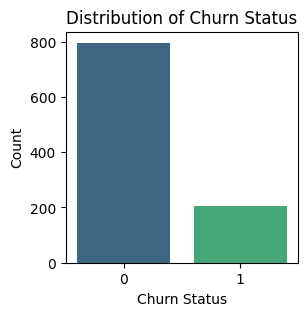

In [103]:
plt.figure(figsize=(3, 3))
sns.countplot(x='ChurnStatus', data=master_df, palette='viridis')
plt.title('Distribution of Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Count')
plt.show()

## **Feature Engineering**

In [104]:
# --- STEP: RFM FEATURE ENGINEERING ---

# 1. Recency (Days since last login) - Higher is better (5)
master_df['R_Score'] = pd.qcut(master_df['Recency_Login'], 5, labels=[5, 4, 3, 2, 1])

# 2. Frequency (Transaction Count) - Higher is better (5)
master_df['F_Score'] = pd.qcut(master_df['Transaction_Count'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# 3. Monetary (Total Spend) - Higher is better (5)
master_df['M_Score'] = pd.qcut(master_df['Total_spend'], 5, labels=[1, 2, 3, 4, 5])

# 4. Combine into a single RFM Score
# We convert them to strings to create a '555' or '111' style code
master_df['RFM_Sum'] = master_df['R_Score'].astype(int) + master_df['F_Score'].astype(int) + master_df['M_Score'].astype(int)

# --- STEP: INTERACTION FEATURES ---
master_df['Login_Consistency'] = master_df['Total_Logins'] / (master_df['Recency_Login'] + 1)
master_df['Spend_Efficiency'] = master_df['Total_spend'] / (master_df['Transaction_Count'] + 1)
master_df['Service_Friction'] = master_df['Unresolved_Issues'] / (master_df['Total_Service_Calls'] + 1)

In [105]:
master_df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,Total_Logins,Recency_Login,Service,Last_Login_Month,Total_spend,...,Total_Service_Calls,Unresolved_Issues,ChurnStatus,R_Score,F_Score,M_Score,RFM_Sum,Login_Consistency,Spend_Efficiency,Service_Friction
0,1,62,M,Single,Low,34,72,Mobile App,October,416.50,...,1.0,0.0,0,5,1,1,7,0.465753,208.250000,0.000000
1,2,65,M,Married,Low,5,27,Website,December,1547.42,...,1.0,0.0,1,5,4,4,13,0.178571,193.427500,0.000000
2,3,18,M,Single,Low,3,47,Website,November,1702.98,...,1.0,0.0,0,5,3,4,12,0.062500,243.282857,0.000000
3,4,21,M,Widowed,Low,2,129,Website,August,917.29,...,2.0,1.0,0,4,3,2,9,0.015385,152.881667,0.333333
4,5,21,M,Divorced,Medium,41,66,Website,October,2001.49,...,0.0,0.0,0,5,4,5,14,0.611940,222.387778,0.000000


## **Data Preprocessing for Machine Learning**

In [106]:
master_df.columns.tolist()

['CustomerID',
 'Age',
 'Gender',
 'MaritalStatus',
 'IncomeLevel',
 'Total_Logins',
 'Recency_Login',
 'Service',
 'Last_Login_Month',
 'Total_spend',
 'Transaction_Count',
 'Most_Frequent_Product_Category',
 'Distinct_Product_Categories',
 'Number_of_Active_Months',
 'Most_Active_Month',
 'Total_Service_Calls',
 'Unresolved_Issues',
 'ChurnStatus',
 'R_Score',
 'F_Score',
 'M_Score',
 'RFM_Sum',
 'Login_Consistency',
 'Spend_Efficiency',
 'Service_Friction']

In [107]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   CustomerID                      1000 non-null   int64   
 1   Age                             1000 non-null   int64   
 2   Gender                          1000 non-null   object  
 3   MaritalStatus                   1000 non-null   object  
 4   IncomeLevel                     1000 non-null   object  
 5   Total_Logins                    1000 non-null   int64   
 6   Recency_Login                   1000 non-null   int64   
 7   Service                         1000 non-null   object  
 8   Last_Login_Month                1000 non-null   object  
 9   Total_spend                     1000 non-null   float64 
 10  Transaction_Count               1000 non-null   int64   
 11  Most_Frequent_Product_Category  1000 non-null   object  
 12  Distinct_Product_Cate

In [108]:
master_df['R_Score'] = master_df['R_Score'].astype(int)
master_df['F_Score'] = master_df['F_Score'].astype(int)
master_df['M_Score'] = master_df['M_Score'].astype(int)

### **Identifying Feature Types**

In [109]:
# Drop CustomerID as it's an identifier and not a feature for the model
X = master_df.drop(['CustomerID', 'Total_spend', 'Distinct_Product_Categories', 'ChurnStatus'], axis=1)
y = master_df['ChurnStatus']

categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical Features: {categorical_features}")
print(f"Numerical Features: {numerical_features}")

Categorical Features: ['Gender', 'MaritalStatus', 'IncomeLevel', 'Service', 'Last_Login_Month', 'Most_Frequent_Product_Category', 'Most_Active_Month']
Numerical Features: ['Age', 'Total_Logins', 'Recency_Login', 'Transaction_Count', 'Number_of_Active_Months', 'Total_Service_Calls', 'Unresolved_Issues', 'R_Score', 'F_Score', 'M_Score', 'RFM_Sum', 'Login_Consistency', 'Spend_Efficiency', 'Service_Friction']


### **Encoding Categorical Features**

In [110]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are for now
)

# Apply the preprocessing to X
X_encoded = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# This creates new column names based on the original category and its values
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(encoded_feature_names) + numerical_features

# Convert the processed data back to a DataFrame
X_processed = pd.DataFrame(X_encoded, columns=all_feature_names)

print("Shape of original X:", X.shape)
print("Shape of X after one-hot encoding:", X_processed.shape)
print("First 5 rows of processed X:")
display(X_processed.head())

Shape of original X: (1000, 21)
Shape of X after one-hot encoding: (1000, 55)
First 5 rows of processed X:


,Gender_F,Gender_M,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_High,IncomeLevel_Low,IncomeLevel_Medium,Service_Mobile App,...,Number_of_Active_Months,Total_Service_Calls,Unresolved_Issues,R_Score,F_Score,M_Score,RFM_Sum,Login_Consistency,Spend_Efficiency,Service_Friction
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,5.0,1.0,1.0,7.0,0.465753,208.250000,0.000000
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,5.0,1.0,0.0,5.0,4.0,4.0,13.0,0.178571,193.427500,0.000000
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,6.0,1.0,0.0,5.0,3.0,4.0,12.0,0.062500,243.282857,0.000000
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,3.0,2.0,1.0,4.0,3.0,2.0,9.0,0.015385,152.881667,0.333333
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,6.0,0.0,0.0,5.0,4.0,5.0,14.0,0.611940,222.387778,0.000000


### **Scaling Numerical Features**

In [111]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical features in X_processed
X_processed[numerical_features] = scaler.fit_transform(X_processed[numerical_features])

print("Numerical features in X_processed scaled successfully.")
print("First 5 rows of processed X with scaled numerical features:")
display(X_processed.head())

Numerical features in X_processed scaled successfully.
First 5 rows of processed X with scaled numerical features:


,Gender_F,Gender_M,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_High,IncomeLevel_Low,IncomeLevel_Medium,Service_Mobile App,...,Number_of_Active_Months,Total_Service_Calls,Unresolved_Issues,R_Score,F_Score,M_Score,RFM_Sum,Login_Consistency,Spend_Efficiency,Service_Friction
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,-1.584584,-0.002451,-0.771419,1.408576,-1.414214,-1.414214,-0.644443,0.005984,0.189404,-0.787274
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.457406,-0.002451,-0.771419,1.408576,0.707107,0.707107,1.285028,-0.167051,-0.041376,-0.787274
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.967903,-0.002451,-0.771419,1.408576,0.000000,0.707107,0.963449,-0.236987,0.734850,-0.787274
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.563589,1.222911,0.839059,0.702877,0.000000,-0.707107,-0.001286,-0.265376,-0.672656,0.631237
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.967903,-1.227812,-0.771419,1.408576,0.707107,1.414214,1.606607,0.094065,0.409523,-0.787274


In [112]:
X_processed.shape

(1000, 55)

In [113]:
y.head()

,ChurnStatus
0,0
1,1
2,0
3,0
4,0


In [114]:
y.shape

(1000,)

# **TASK 2**

## **Data Splitting**

In [115]:
from sklearn.model_selection import train_test_split

# X_processed is your scaled/encoded features, y is your target
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data split successfully. Training rows: {len(X_train)}, Test rows: {len(X_test)}")

Data split successfully. Training rows: 800, Test rows: 200


## **1. Baseline Logistic Regression**

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize and train
log_baseline = LogisticRegression(max_iter=1000, random_state=42)
log_baseline.fit(X_train, y_train)

# Predict
y_pred_log = log_baseline.predict(X_test)
y_prob_log = log_baseline.predict_proba(X_test)[:, 1]

### **Model Evaluation LR**

In [117]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print("--- BASELINE: LOGISTIC REGRESSION ---")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_log):.2f}")

--- BASELINE: LOGISTIC REGRESSION ---
Accuracy: 0.79
Precision: 0.00
Recall: 0.00
F1-Score: 0.00

Confusion Matrix:
[[158   1]
 [ 41   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.99      0.88       159
           1       0.00      0.00      0.00        41

    accuracy                           0.79       200
   macro avg       0.40      0.50      0.44       200
weighted avg       0.63      0.79      0.70       200

ROC-AUC: 0.50


## **2. Advanced Random Forest**

In [118]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 1. Apply SMOTE ONLY to training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced', # <--- THIS IS THE KEY
    max_depth=10,
    random_state=42
)

# 3. Cross-Validation (on resampled training data to check stability)
cv_scores = cross_val_score(rf_model, X_train_resampled, y_train_resampled, cv=5, scoring='f1')
print(f"RF Cross-Val F1 Score: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")

# 4. Train the final model on resampled training data
rf_model.fit(X_train_resampled, y_train_resampled)

RF Cross-Val F1 Score: 0.80 (+/- 0.33)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

### **Model Evaluation RF**

In [119]:
# Predict on the PURE test set
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Force the model to be aggressive
y_pred_new = (y_probs >= 0.35).astype(int)

accuracy_new = accuracy_score(y_test, y_pred_new)
precision_new = precision_score(y_test, y_pred_new)
recall_new = recall_score(y_test, y_pred_new)
f1_new = f1_score(y_test, y_pred_new)

print("--- ADVANCED: RANDOM FOREST ---")
print(f"Accuracy: {accuracy_new:.2f}")
print(f"Precision: {precision_new:.2f}")
print(f"Recall: {recall_new:.2f}")
print(f"F1-Score: {f1_new}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_new))

print("--- Aggressive Threshold Results ---")
print(classification_report(y_test, y_pred_new))

print(f"ROC-AUC: {roc_auc_score(y_test, y_probs):.2f}")

--- ADVANCED: RANDOM FOREST ---
Accuracy: 0.66
Precision: 0.20
Recall: 0.22
F1-Score: 0.20689655172413793

Confusion Matrix:
[[122  37]
 [ 32   9]]
--- Aggressive Threshold Results ---
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       159
           1       0.20      0.22      0.21        41

    accuracy                           0.66       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.67      0.66      0.66       200

ROC-AUC: 0.53


#### **Random Forest Feature Importance**

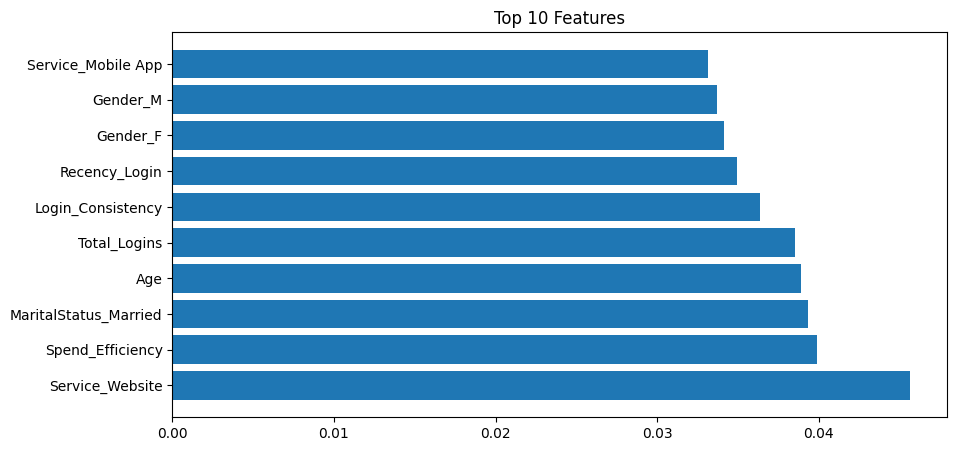

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.title("Top 10 Features")
plt.show()

In [121]:
feature_importance_df.head(10)

,Feature,Importance
11,Service_Website,0.045667
53,Spend_Efficiency,0.039889
3,MaritalStatus_Married,0.039343
41,Age,0.038896
42,Total_Logins,0.038540
52,Login_Consistency,0.036339
43,Recency_Login,0.034931
0,Gender_F,0.034112
1,Gender_M,0.033698
9,Service_Mobile App,0.033150


### **Hyperparameter Tuning RF**

In [123]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Filter X to only include your Top 10 Features
# (Update this list based on your importance plot: Recency, Total Logins, Age, etc.)
top_10_features_rf = [
    'Service_Website', 'Spend_Efficiency', 'MaritalStatus_Married', 'Age',
    'Total_Logins', 'Login_Consistency', 'Recency_Login', 'Gender_F',
    'Gender_M', 'Service_Mobile App'
]

X_top = X_train[top_10_features_rf]
X_test_top = X_test[top_10_features_rf]

# 2. Define the Parameter Grid
# We are testing different 'depths' and 'strengths' of the forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}

# 3. Initialize RandomizedSearchCV
# We use scoring='roc_auc' because we want to improve that 0.49 score
randomized_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid, # Corrected argument name
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

# 4. Run the Search
print("Starting Hyperparameter Tuning RF...")
randomized_search.fit(X_top, y_train)

# 5. Extract the Best Model
best_rf = randomized_search.best_estimator_
print(f"\nBest Parameters: {randomized_search.best_params_}")

# 6. Final Evaluation
y_probs_tuned = best_rf.predict_proba(X_test_top)[:, 1]
y_pred_tuned = (y_probs_tuned >= 0.35).astype(int) # Keeping your aggressive threshold

print("\n--- TUNED MODEL EVALUATION (TOP 10 FEATURES) ---")
print(f"ROC-AUC: {roc_auc_score(y_test, y_probs_tuned):.2f}")

accuracy_score = accuracy_score(y_test, y_pred_tuned)
precision_score = precision_score(y_test, y_pred_tuned)
recall_score = recall_score(y_test, y_pred_tuned)
f1_score = f1_score(y_test, y_pred_tuned)

print(f"Accuracy: {accuracy_score:.2f}")
print(f"Precision: {precision_score:.2f}")
print(f"Recall: {recall_score:.2f}")
print(f"F1-Score: {f1_score:.2f}")

print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))
print(f"Final Tuned ROC-AUC: {roc_auc_score(y_test, y_probs_tuned):.2f}")

Starting Hyperparameter Tuning RF...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 15, 'class_weight': 'balanced'}

--- TUNED MODEL EVALUATION (TOP 10 FEATURES) ---
ROC-AUC: 0.51
Accuracy: 0.63
Precision: 0.24
Recall: 0.37
F1-Score: 0.29
[[111  48]
 [ 26  15]]
              precision    recall  f1-score   support

           0       0.81      0.70      0.75       159
           1       0.24      0.37      0.29        41

    accuracy                           0.63       200
   macro avg       0.52      0.53      0.52       200
weighted avg       0.69      0.63      0.66       200

Final Tuned ROC-AUC: 0.51


## **3. XGBoost**

In [124]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# 1. Apply SMOTE ONLY to training data (copied from previous section)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Calculate scale_pos_weight for handling class imbalance with XGBoost
# It's recommended to use sum(negative instances) / sum(positive instances)
neg_count = y_train_resampled.value_counts()[0] # Count of non-churn (0)
pos_count = y_train_resampled.value_counts()[1] # Count of churn (1)
scale_pos_weight_value = neg_count / pos_count

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(
    objective='binary:logistic', # For binary classification
    use_label_encoder=False,     # Suppress warning for older sklearn versions
    eval_metric='logloss',       # Evaluation metric for binary classification
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.1,
    scale_pos_weight=scale_pos_weight_value, # Handle imbalance, alternative to class_weight
    random_state=42
)

# Cross-Validation on resampled training data
cv_scores_xgb = cross_val_score(xgb_model, X_train_resampled, y_train_resampled, cv=5, scoring='f1', n_jobs=-1)
print(f"XGBoost Cross-Val F1 Score: {cv_scores_xgb.mean():.2f} (+/- {cv_scores_xgb.std():.2f})")

# Train the final XGBoost model on resampled training data
xgb_model.fit(X_train_resampled, y_train_resampled)

XGBoost Cross-Val F1 Score: 0.75 (+/- 0.36)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:45:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

### **Model Evaluation XGB**

In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Predict probabilities on the PURE test set
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Apply the aggressive threshold (0.35) for prediction
y_pred_xgb = (y_probs_xgb >= 0.35).astype(int)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_probs_xgb)

print("--- ADVANCED: XGBOOST MODEL ---")
print(f"Accuracy: {accuracy_xgb:.2f}")
print(f"Precision: {precision_xgb:.2f}")
print(f"Recall: {recall_xgb:.2f}")
print(f"F1-Score: {f1_xgb:.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("--- Aggressive Threshold Results ---")
print(classification_report(y_test, y_pred_xgb))

print(f"ROC-AUC: {roc_auc_xgb:.2f}")

--- ADVANCED: XGBOOST MODEL ---
Accuracy: 0.70
Precision: 0.22
Recall: 0.17
F1-Score: 0.19

Confusion Matrix:
[[134  25]
 [ 34   7]]
--- Aggressive Threshold Results ---
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       159
           1       0.22      0.17      0.19        41

    accuracy                           0.70       200
   macro avg       0.51      0.51      0.51       200
weighted avg       0.68      0.70      0.69       200

ROC-AUC: 0.50


#### **XGBoost Feature Importance**

Top 10 XGBoost Features:


,Feature,Importance
3,MaritalStatus_Married,0.062958
7,IncomeLevel_Low,0.041885
11,Service_Website,0.040683
20,Last_Login_Month_May,0.038224
39,Most_Active_Month_October,0.035529
9,Service_Mobile App,0.032850
4,MaritalStatus_Single,0.032459
2,MaritalStatus_Divorced,0.030788
1,Gender_M,0.026497
37,Most_Active_Month_May,0.025970


/tmp/ipykernel_16151/1516273537.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb.head(10), palette='viridis')


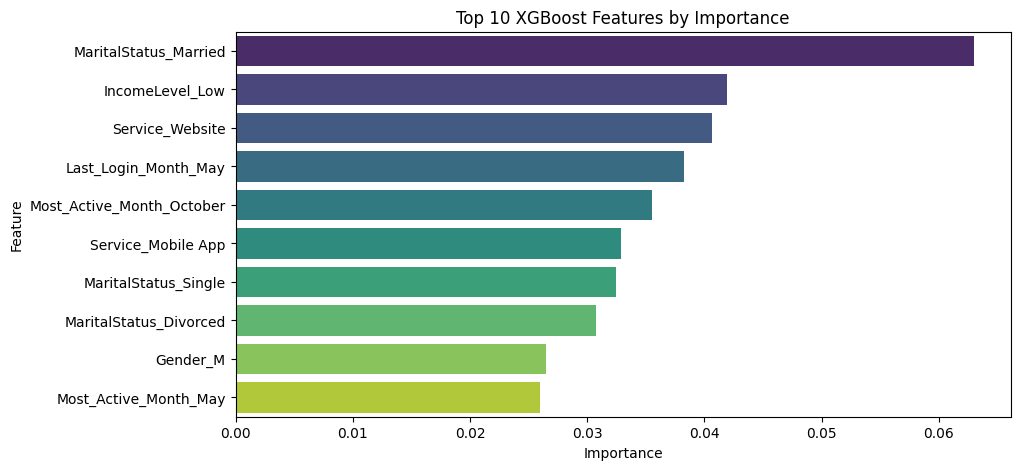

In [126]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the trained XGBoost model
importances_xgb = xgb_model.feature_importances_
feature_names_xgb = X_train.columns # Use the original feature names from X_train

# Create a DataFrame for better visualization
feature_importance_df_xgb = pd.DataFrame({'Feature': feature_names_xgb, 'Importance': importances_xgb})
feature_importance_df_xgb = feature_importance_df_xgb.sort_values(by='Importance', ascending=False)

# Display the top 10 features
print("Top 10 XGBoost Features:")
display(feature_importance_df_xgb.head(10))

# Plot the top 10 features
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb.head(10), palette='viridis')
plt.title("Top 10 XGBoost Features by Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### **Hyperparameter Tuning XGB**

In [130]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# 1. Filter X to only include your Top 10 Features
# (Update this list based on your importance plot: Recency, Total Logins, Age, etc.)
top_10_features_xgb = [
    'MaritalStatus_Married', 'IncomeLevel_Low', 'Service_Website', 'Last_Login_Month_May',
    'Most_Active_Month_October', 'Service_Mobile App', 'MaritalStatus_Single', 'MaritalStatus_Divorced',
    'Gender_M', 'Most_Active_Month_May'
]

X_top = X_train[top_10_features_xgb]
X_test_top = X_test[top_10_features_xgb]

# Recalculate scale_pos_weight for tuning, using the resampled training data if SMOTE is applied for tuning
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train[top_10_features_xgb], y_train)
neg_count = y_train_resampled.value_counts()[0]
pos_count = y_train_resampled.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

# 2. Define the Parameter Grid with XGBoost-specific parameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    #'subsample': [0.7, 0.8, 0.9],
    #'colsample_bytree': [0.7, 0.8, 0.9],
    #'gamma': [0, 0.1, 0.2],
    #'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [scale_pos_weight_value] # Use the calculated value or experiment with a range
}

# 3. Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False, # Suppress warning
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

# 4. Run the Search
print("Starting Hyperparameter Tuning XGB...")
# Fit on the original training data (X_top, y_train) if SMOTE is handled via scale_pos_weight
# If SMOTE resampled data was used, fit on X_train_resampled, y_train_resampled
grid_search_xgb.fit(X_top, y_train)

# 5. Extract the Best Model
best_xgb = grid_search_xgb.best_estimator_
print(f"\nBest Parameters: {grid_search_xgb.best_params_}")

# 6. Final Evaluation
y_probs_tuned = best_xgb.predict_proba(X_test_top)[:, 1]
y_pred_tuned = (y_probs_tuned >= 0.35).astype(int) # Keeping your aggressive threshold

print("\n--- TUNED MODEL EVALUATION (TOP 10 FEATURES) ---")
print(f"ROC-AUC: {roc_auc_score(y_test, y_probs_tuned):.2f}")

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"Accuracy: {accuracy_tuned:.2f}")
print(f"Precision: {precision_tuned:.2f}")
print(f"Recall: {recall_tuned:.2f}")
print(f"F1-Score: {f1_tuned:.2f}")

print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))
print(f"Final Tuned ROC-AUC: {roc_auc_score(y_test, y_probs_tuned):.2f}")

Starting Hyperparameter Tuning XGB...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:06:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'scale_pos_weight': np.float64(1.0)}

--- TUNED MODEL EVALUATION (TOP 10 FEATURES) ---
ROC-AUC: 0.51
Accuracy: 0.73
Precision: 0.17
Recall: 0.07
F1-Score: 0.10
[[144  15]
 [ 38   3]]
              precision    recall  f1-score   support

           0       0.79      0.91      0.84       159
           1       0.17      0.07      0.10        41

    accuracy                           0.73       200
   macro avg       0.48      0.49      0.47       200
weighted avg       0.66      0.73      0.69       200

Final Tuned ROC-AUC: 0.51


## **Pipeline**

In [132]:
from sklearn.base import BaseEstimator, TransformerMixin

class LloydsFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, top_features):
        self.top_features = top_features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # The features 'Login_Consistency' and 'Spend_Efficiency' are already created earlier in the notebook
        # and are expected to be present in the X DataFrame passed to the pipeline.
        # This transformer will now only select the top features.
        return X[self.top_features]

In [133]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Define your winning features from the grid search
top_10_features = [
    'Service_Website', 'Spend_Efficiency', 'MaritalStatus_Married', 'Age',
    'Total_Logins', 'Login_Consistency', 'Recency_Login', 'Gender_F',
    'Gender_M', 'Service_Mobile App'
]

# 2. Build the "Assembly Line"
production_pipeline = Pipeline([
    ('engineer', LloydsFeatureEngineer(top_features=top_10_features)),
    ('scaler', StandardScaler()),
    ('classifier', best_xgb) # This is the model you just tuned!
])

# 3. Fit it one last time on the training data
production_pipeline.fit(X_train, y_train)

# 4. Save it as a physical file
joblib.dump(production_pipeline, 'lloyds_churn_prod_v1.pkl')
print("Model Exported Successfully!")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:09:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Exported Successfully!


In [134]:
# Create a "New Customer" (Raw Data)
new_customer = pd.DataFrame([{
    'Total_Logins': 5,
    'Recency_Login': 20,
    'Spend_Efficiency': 500 / (2 + 1), # Calculate Spend_Efficiency based on Total_Spend and Transaction_Count
    'Age': 25,
    'Service_Website': 1,
    'MaritalStatus_Married': 0,
    'Gender_F': 1,
    'Gender_M': 0,
    'Service_Mobile App': 0,
    'Login_Consistency': 5 / (20 + 1) # Calculate Login_Consistency based on Total_Logins and Recency_Login
}])

# Ensure the columns match the `top_10_features` order for consistency
new_customer = new_customer[top_10_features]

# Load the model back up (just like a production server would)
deployed_model = joblib.load('lloyds_churn_prod_v1.pkl')

# Get the prediction
risk_probability = deployed_model.predict_proba(new_customer)[:, 1][0]
prediction = "ACTION REQUIRED" if risk_probability >= 0.35 else "STABLE"

print(f"Customer Churn Risk: {risk_probability:.2%}")
print(f"Recommendation: {prediction}")

Customer Churn Risk: 68.66%
Recommendation: ACTION REQUIRED
